# Classification supervisée des types de cancer

## 1. Importation des bibliothèques

In [3]:
import sys
!{sys.executable} -m pip install optuna xgboost imbalanced-learn

import warnings
import json
from pathlib import Path
from typing import Any
from types import SimpleNamespace

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import randint, loguniform, uniform
from IPython.display import display

from sklearn.base import BaseEstimator, ClassifierMixin, clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score, make_scorer, roc_curve, auc, roc_auc_score
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, StratifiedKFold, RepeatedStratifiedKFold, train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder, StandardScaler, label_binarize
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.calibration import CalibratedClassifierCV

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
RUN_XGBOOST = True  # mettre False si l'exécution est trop longue ou si xgboost n'est pas installé


## 2. Chargement et aperçu des données

In [4]:
def find_data_file() -> Path:
    candidates = [Path("data/donnee_etu.xlsx"), Path("donnee_etu.xlsx"), Path("/mnt/data/donnee_etu.xlsx")]
    for path in candidates:
        if path.exists():
            return path
    raise FileNotFoundError("Placez donnee_etu.xlsx dans le dossier courant ou dans data/.")


data_path = find_data_file()
train_df = pd.read_excel(data_path, sheet_name="train")
validation_df = pd.read_excel(data_path, sheet_name="Validation")

print(f"Fichier utilisé : {data_path}")
print("Train :", train_df.shape)
print("Validation :", validation_df.shape)
display(train_df.head())
display(validation_df.head())

Fichier utilisé : donnee_etu.xlsx
Train : (598, 10)
Validation : (75, 10)


,age,Type,marqueur 2,marqueur 3,marqueur 4,marqueur 5,marqueur 6,marqueur 7,marqueur 8,marqueur 9
0,82.0,4,NEG,NEG,POS,POS,960.0,480.0,200.0,13730.0
1,81.0,4,NEG,NEG,NEG,POS,970.0,1800.0,310.0,19500.0
2,64.0,1,POS,NEG,POS,NEG,920.0,1350.0,7140.0,2840.0
3,74.0,6,NEG,NEG,NEG,POS,2030.0,850.0,100.0,51500.0
4,72.0,4,NEG,NEG,NEG,POS,650.0,1410.0,3180.0,81300.0


,age,Type,marqueur 2,marqueur 3,marqueur 4,marqueur 5,marqueur 6,marqueur 7,marqueur 8,marqueur 9
0,63,NaN,NEG,NEG,NEG,POS,560.0,4710,13210,NaN
1,16,NaN,NEG,POS,POS,POS,520.0,1080,1620,18100.0
2,78,NaN,NEG,NEG,NEG,POS,1870.0,520,2780,45450.0
3,52,NaN,POS,NEG,POS,NEG,510.0,1360,6460,2560.0
4,63,NaN,NEG,NEG,NEG,POS,480.0,5750,16040,168220.0


## 3. Exploration rapide : valeurs manquantes et distribution de la cible

Types de variables :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 598 entries, 0 to 597
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   age         597 non-null    float64
 1   Type        598 non-null    int64  
 2   marqueur 2  596 non-null    object 
 3   marqueur 3  594 non-null    object 
 4   marqueur 4  592 non-null    object 
 5   marqueur 5  597 non-null    object 
 6   marqueur 6  596 non-null    float64
 7   marqueur 7  594 non-null    float64
 8   marqueur 8  596 non-null    float64
 9   marqueur 9  573 non-null    float64
dtypes: float64(5), int64(1), object(4)
memory usage: 46.8+ KB

Valeurs manquantes :


,missing_values
age,1
Type,0
marqueur 2,2
marqueur 3,4
marqueur 4,6
marqueur 5,1
marqueur 6,2
marqueur 7,4
marqueur 8,2
marqueur 9,25



Distribution de Type :


,effectif
Type,
1,194
2,21
3,27
4,146
5,65
6,145


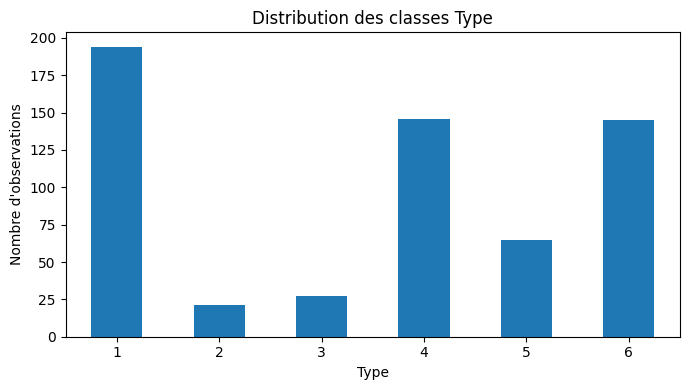

In [5]:
print("Types de variables :")
train_df.info()

print("\nValeurs manquantes :")
display(train_df.isna().sum().to_frame("missing_values"))

print("\nDistribution de Type :")
type_counts = train_df["Type"].value_counts().sort_index()
display(type_counts.to_frame("effectif"))

plt.figure(figsize=(7, 4))
type_counts.plot(kind="bar")
plt.title("Distribution des classes Type")
plt.xlabel("Type")
plt.ylabel("Nombre d'observations")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 4. Nettoyage léger des catégories

In [6]:
def clean_categorical_values(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    for col in df.select_dtypes(include="object").columns:
        df[col] = (
            df[col].astype(str).str.strip().str.upper()
            .replace({"NAN": np.nan, "<NA>": np.nan, "NONE": np.nan, "": np.nan})
        )
    return df

train_df = clean_categorical_values(train_df)
validation_df = clean_categorical_values(validation_df)

## 5. 🎯 Définition des variables cibles et explicatives

In [7]:
X = train_df.drop(columns=["Type"])
y = train_df["Type"].astype(int)
X_validation = validation_df.drop(columns=["Type"], errors="ignore")

print("X :", X.shape)
print("y :", y.shape)
print("X_validation :", X_validation.shape)
print("Classes :", sorted(y.unique()))

X : (598, 9)
y : (598,)
X_validation : (75, 9)
Classes : [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]


## 6. 📊 Division entraînement/test

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

print("X_train :", X_train.shape)
print("X_test :", X_test.shape)
display(y_train.value_counts().sort_index().to_frame("train"))
display(y_test.value_counts().sort_index().to_frame("test"))

X_train : (478, 9)
X_test : (120, 9)


,train
Type,
1,155
2,17
3,21
4,117
5,52
6,116


,test
Type,
1,39
2,4
3,6
4,29
5,13
6,29


## 7. Prétraitement commun pour tous les modèles

In [9]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import RepeatedStratifiedKFold, StratifiedKFold
from sklearn.metrics import make_scorer, f1_score

def make_one_hot_encoder() -> OneHotEncoder:
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

def split_columns(X_data: pd.DataFrame) -> tuple[list[str], list[str]]:
    numeric_cols = X_data.select_dtypes(include=[np.number]).columns.tolist()
    categorical_cols = [c for c in X_data.columns if c not in numeric_cols]
    return numeric_cols, categorical_cols

def build_preprocessor(X_data: pd.DataFrame) -> ColumnTransformer:
    numeric_cols, categorical_cols = split_columns(X_data)

    numeric_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])

    categorical_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", make_one_hot_encoder()),
    ])

    return ColumnTransformer([
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols),
    ])

# Sécurité : On ne construit le preprocessor que si X_train existe
try:
    preprocessor = build_preprocessor(X_train)
    print("Préprocesseur initialisé avec succès.")
except NameError:
    preprocessor = None
    print("Note : X_train non défini. Le préprocesseur sera initialisé après l'exécution de la Section 6.")

# Configuration de la validation croisée
CV_N_SPLITS = 5
CV_N_REPEATS = 3
# RANDOM_STATE doit être défini (généralement en Section 1)
_rs = globals().get('RANDOM_STATE', 42)

cv = RepeatedStratifiedKFold(
    n_splits=CV_N_SPLITS,
    n_repeats=CV_N_REPEATS,
    random_state=_rs,
)

cv_light = StratifiedKFold(n_splits=5, shuffle=True, random_state=_rs)
scorer = make_scorer(f1_score, average="macro", zero_division=0)

# Paramètres globaux de recherche et d'activation
N_JOBS_SEARCH = -1
VERBOSE_SEARCH = 1
N_ITER_DT = 120
N_ITER_RF = 120
N_ITER_SVM = 100
N_ITER_XGB = 100
N_ITER_SMOTE = 70
N_TRIALS_OPTUNA = 50

RUN_SMOTE = True
RUN_OPTUNA = True
RUN_THRESHOLD_OPTIMIZATION = True

print(f"Validation croisée : {CV_N_SPLITS} folds x {CV_N_REPEATS} répétitions")
print(f"Optimisation des seuils activée : {RUN_THRESHOLD_OPTIMIZATION}")

Préprocesseur initialisé avec succès.
Validation croisée : 5 folds x 3 répétitions
Optimisation des seuils activée : True


## 8. Fonctions d'évaluation et de visualisation

In [10]:
results_rows: list[dict[str, Any]] = []
fitted_models: dict[str, dict[str, Any]] = {}


def _clean_param_value(value):
    if isinstance(value, np.generic):
        return value.item()
    return value


def clean_params(params: dict[str, Any]) -> dict[str, Any]:
    return {k: _clean_param_value(v) for k, v in params.items()}


def params_to_string(params: dict[str, Any]) -> str:
    try:
        return json.dumps(clean_params(params), ensure_ascii=False, sort_keys=True)
    except Exception:
        return str(params)


def search_cv_std(search: Any) -> float:
    if not hasattr(search, "cv_results_") or not hasattr(search, "best_index_"):
        return np.nan
    std_scores = search.cv_results_.get("std_test_score")
    if std_scores is None:
        return np.nan
    return float(std_scores[search.best_index_])


def add_result_row(
    *,
    name: str,
    estimator: Any,
    y_pred: np.ndarray,
    cv_mean: float | None,
    cv_std: float | None,
    best_params: dict[str, Any] | None,
    variant: str,
    eligible_for_final: bool = True,
    search: Any | None = None,
) -> None:
    row = {
        "model": name,
        "variant": variant,
        "cv_f1_macro": np.nan if cv_mean is None else float(cv_mean),
        "cv_f1_macro_std": np.nan if cv_std is None else float(cv_std),
        "test_accuracy": accuracy_score(y_test, y_pred),
        "test_balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
        "test_f1_macro": f1_score(y_test, y_pred, average="macro", zero_division=0),
        "best_params": "" if best_params is None else params_to_string(best_params),
        "eligible_for_final": eligible_for_final,
    }
    results_rows.append(row)
    fitted_models[name] = {
        "search": search,
        "best_estimator": estimator,
        "y_pred": y_pred,
        "variant": variant,
        "eligible_for_final": eligible_for_final,
    }


def evaluate_search(name: str, search: Any, variant: str = "Recherche hyperparamètres + CV répétée") -> None:
    print()
    print(f"===== Recherche d'hyperparamètres : {name} =====")
    search.fit(X_train, y_train)
    y_pred = search.predict(X_test)

    add_result_row(
        name=name,
        estimator=search.best_estimator_,
        y_pred=y_pred,
        cv_mean=search.best_score_,
        cv_std=search_cv_std(search),
        best_params=search.best_params_,
        variant=variant,
        eligible_for_final=True,
        search=search,
    )

    row = results_rows[-1]
    display(pd.DataFrame([row]).drop(columns=["best_params"]))
    print("Meilleur score CV F1-macro :", round(search.best_score_, 4))
    print("Écart-type CV             :", round(search_cv_std(search), 4))
    print("Meilleurs paramètres      :", search.best_params_)
    print()
    print("Rapport de classification :")
    print(classification_report(y_test, y_pred, zero_division=0))


def plot_confusion(y_true, y_pred, title: str) -> None:
    labels = sorted(pd.Series(y_true).unique())
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    disp = ConfusionMatrixDisplay(cm, display_labels=labels)
    fig, ax = plt.subplots(figsize=(6, 5))
    disp.plot(ax=ax, values_format="d")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()


def build_comparison_df() -> pd.DataFrame:
    df = pd.DataFrame(results_rows)
    if df.empty:
        return df
    return df.sort_values(
        ["eligible_for_final", "cv_f1_macro", "test_f1_macro"],
        ascending=[False, False, False],
    ).reset_index(drop=True)


def get_best_eligible_model_name(df: pd.DataFrame) -> str:
    eligible_df = df[df["eligible_for_final"] == True].copy()
    if eligible_df.empty:
        raise ValueError("Aucun modèle éligible pour la soumission finale.")
    return eligible_df.sort_values(["cv_f1_macro", "test_f1_macro"], ascending=[False, False]).iloc[0]["model"]

## 9. 🧪 Modèle de base : Régression Logistique Multiclasse

In [11]:
lr_pipe = Pipeline([
    ("preprocess", preprocessor),
    ("clf", LogisticRegression(max_iter=10000, random_state=RANDOM_STATE)),
])

# Recherche plus complète : régularisation, solveur et pondération des classes.
lr_grid = {
    "clf__C": np.logspace(-4, 4, 17),
    "clf__solver": ["lbfgs", "newton-cg", "saga"],
    "clf__class_weight": [None, "balanced"],
}

lr_search = GridSearchCV(
    lr_pipe,
    lr_grid,
    cv=cv,
    scoring=scorer,
    n_jobs=N_JOBS_SEARCH,
    refit=True,
    verbose=VERBOSE_SEARCH,
    return_train_score=True,
)

evaluate_search("Régression Logistique", lr_search)



===== Recherche d'hyperparamètres : Régression Logistique =====
Fitting 15 folds for each of 102 candidates, totalling 1530 fits


,model,variant,cv_f1_macro,cv_f1_macro_std,test_accuracy,test_balanced_accuracy,test_f1_macro,eligible_for_final
0,Régression Logistique,Recherche hyperparamètres + CV répétée,0.798731,0.048999,0.808333,0.794798,0.784447,True


Meilleur score CV F1-macro : 0.7987
Écart-type CV             : 0.049
Meilleurs paramètres      : {'clf__C': np.float64(1.0), 'clf__class_weight': None, 'clf__solver': 'newton-cg'}

Rapport de classification :
              precision    recall  f1-score   support

           1       0.92      0.90      0.91        39
           2       0.67      0.50      0.57         4
           3       0.86      1.00      0.92         6
           4       0.70      0.72      0.71        29
           5       0.75      0.92      0.83        13
           6       0.81      0.72      0.76        29

    accuracy                           0.81       120
   macro avg       0.78      0.79      0.78       120
weighted avg       0.81      0.81      0.81       120



## 10. 📈 Visualisation des performances de la Régression Logistique

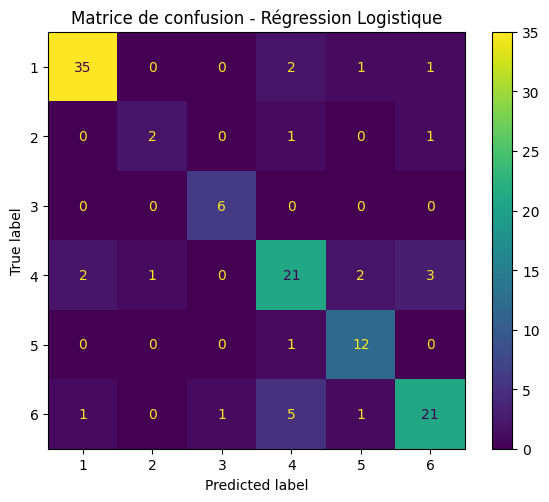

In [12]:
plot_confusion(y_test, fitted_models["Régression Logistique"]["y_pred"], "Matrice de confusion - Régression Logistique")

## 11. 🌳 Modèle : Arbre de Décision

In [13]:
dt_pipe = Pipeline([
    ("preprocess", preprocessor),
    ("clf", DecisionTreeClassifier(random_state=RANDOM_STATE)),
])

# Recherche plus large avec élagage, profondeur, taille minimale des feuilles et pondération.
dt_dist = {
    "clf__criterion": ["gini", "entropy"],
    "clf__max_depth": [2, 3, 4, 5, 6, 8, 10, 12, 15, None],
    "clf__min_samples_split": randint(2, 40),
    "clf__min_samples_leaf": randint(1, 20),
    "clf__max_features": [None, "sqrt", "log2", 0.5, 0.75],
    "clf__class_weight": [None, "balanced"],
    "clf__ccp_alpha": [0.0, 1e-5, 1e-4, 1e-3, 1e-2],
}

dt_search = RandomizedSearchCV(
    dt_pipe,
    dt_dist,
    n_iter=N_ITER_DT,
    cv=cv,
    scoring=scorer,
    random_state=RANDOM_STATE,
    n_jobs=N_JOBS_SEARCH,
    refit=True,
    verbose=VERBOSE_SEARCH,
    return_train_score=True,
)

evaluate_search("Arbre de Décision", dt_search)



===== Recherche d'hyperparamètres : Arbre de Décision =====
Fitting 15 folds for each of 120 candidates, totalling 1800 fits


,model,variant,cv_f1_macro,cv_f1_macro_std,test_accuracy,test_balanced_accuracy,test_f1_macro,eligible_for_final
0,Arbre de Décision,Recherche hyperparamètres + CV répétée,0.741142,0.067316,0.7,0.640399,0.652694,True


Meilleur score CV F1-macro : 0.7411
Écart-type CV             : 0.0673
Meilleurs paramètres      : {'clf__ccp_alpha': 0.001, 'clf__class_weight': None, 'clf__criterion': 'gini', 'clf__max_depth': 12, 'clf__max_features': 0.75, 'clf__min_samples_leaf': 7, 'clf__min_samples_split': 20}

Rapport de classification :
              precision    recall  f1-score   support

           1       0.83      0.77      0.80        39
           2       0.50      0.25      0.33         4
           3       0.80      0.67      0.73         6
           4       0.56      0.66      0.60        29
           5       0.73      0.85      0.79        13
           6       0.68      0.66      0.67        29

    accuracy                           0.70       120
   macro avg       0.68      0.64      0.65       120
weighted avg       0.71      0.70      0.70       120



## 12. 🌳 Visualisation de l'Arbre de Décision optimal

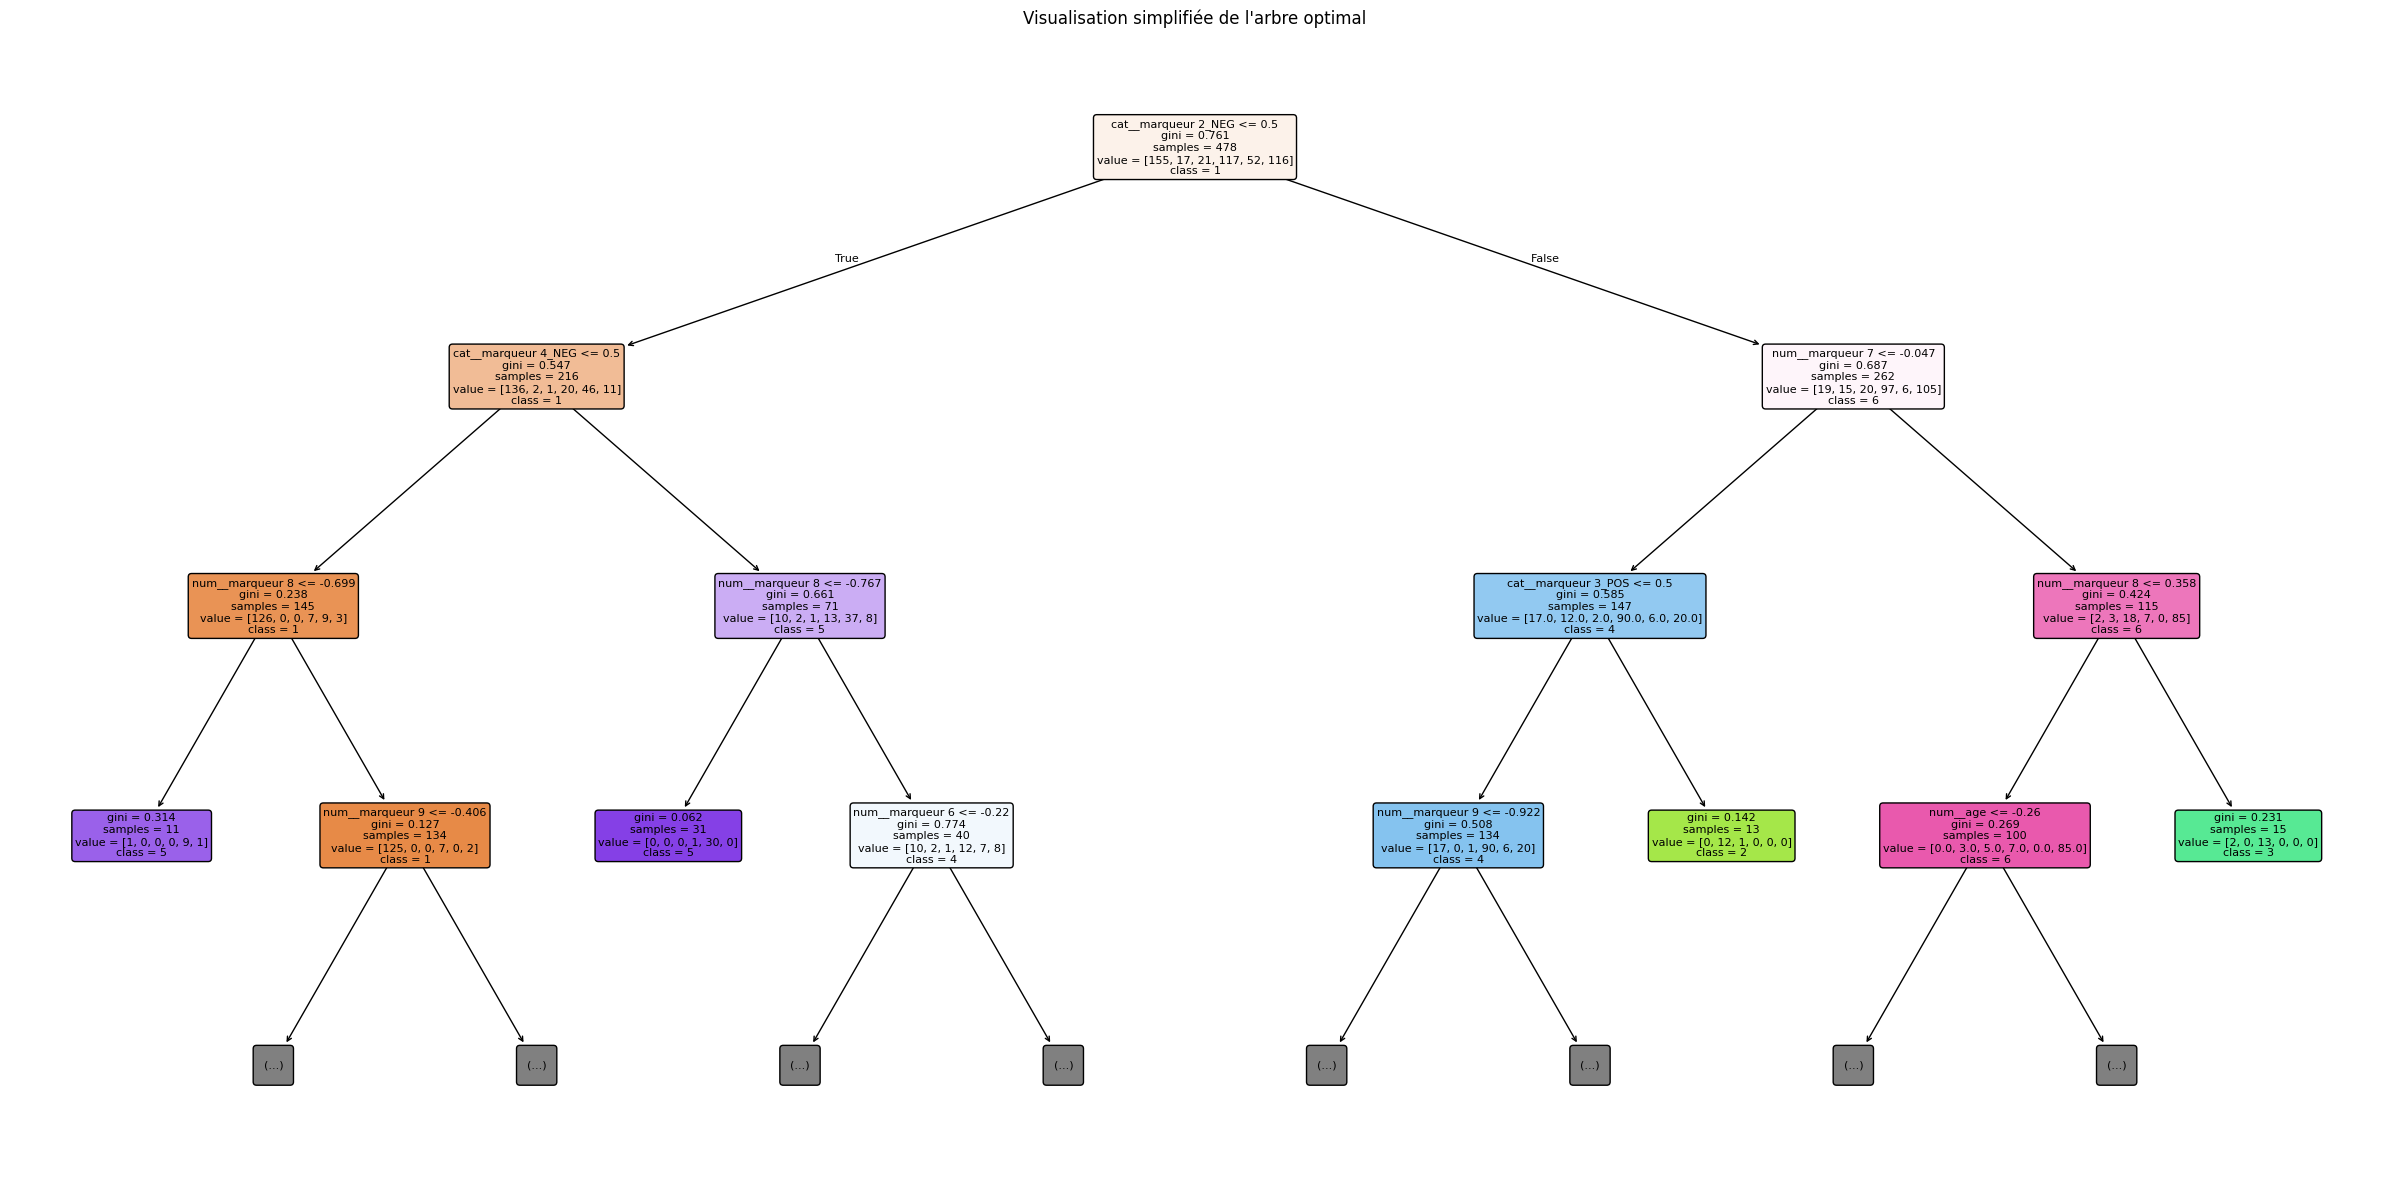

In [14]:
dt_best = fitted_models["Arbre de Décision"]["best_estimator"]
feature_names = dt_best.named_steps["preprocess"].get_feature_names_out()
tree_model = dt_best.named_steps["clf"]

plt.figure(figsize=(24, 12))
plot_tree(
    tree_model,
    feature_names=feature_names,
    class_names=[str(c) for c in tree_model.classes_],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=8,
)
plt.title("Visualisation simplifiée de l'arbre optimal")
plt.tight_layout()
plt.show()

## 13. 🌲 Modèle : Forêt Aléatoire

In [15]:
rf_pipe = Pipeline([
    ("preprocess", preprocessor),
    # n_jobs=1 ici évite une double parallélisation avec RandomizedSearchCV.
    ("clf", RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=1)),
])

# Recherche approfondie : nombre d'arbres, profondeur, régularisation et stratégie de features.
rf_dist = {
    "clf__n_estimators": randint(200, 1000),
    "clf__criterion": ["gini", "entropy"],
    "clf__max_depth": [None, 4, 6, 8, 10, 12, 16, 20, 30, 40],
    "clf__min_samples_split": randint(2, 40),
    "clf__min_samples_leaf": randint(1, 20),
    "clf__max_features": ["sqrt", "log2", 0.3, 0.5, 0.7, None],
    "clf__bootstrap": [True, False],
    "clf__class_weight": [None, "balanced", "balanced_subsample"],
}

rf_search = RandomizedSearchCV(
    rf_pipe,
    rf_dist,
    n_iter=N_ITER_RF,
    cv=cv,
    scoring=scorer,
    random_state=RANDOM_STATE,
    n_jobs=N_JOBS_SEARCH,
    refit=True,
    verbose=VERBOSE_SEARCH,
    return_train_score=True,
)

evaluate_search("Forêt Aléatoire", rf_search)



===== Recherche d'hyperparamètres : Forêt Aléatoire =====
Fitting 15 folds for each of 120 candidates, totalling 1800 fits


,model,variant,cv_f1_macro,cv_f1_macro_std,test_accuracy,test_balanced_accuracy,test_f1_macro,eligible_for_final
0,Forêt Aléatoire,Recherche hyperparamètres + CV répétée,0.810818,0.053208,0.783333,0.755526,0.755576,True


Meilleur score CV F1-macro : 0.8108
Écart-type CV             : 0.0532
Meilleurs paramètres      : {'clf__bootstrap': True, 'clf__class_weight': None, 'clf__criterion': 'gini', 'clf__max_depth': 16, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 9, 'clf__n_estimators': 671}

Rapport de classification :
              precision    recall  f1-score   support

           1       0.92      0.90      0.91        39
           2       0.67      0.50      0.57         4
           3       0.83      0.83      0.83         6
           4       0.66      0.66      0.66        29
           5       0.75      0.92      0.83        13
           6       0.75      0.72      0.74        29

    accuracy                           0.78       120
   macro avg       0.76      0.76      0.76       120
weighted avg       0.78      0.78      0.78       120



## 14. ⚙️ Modèle : Machine à Vecteurs de Support, SVM

In [16]:
svm_pipe = Pipeline([
    ("preprocess", preprocessor),
    ("clf", SVC(random_state=RANDOM_STATE, cache_size=1000)),
])

# Recherche approfondie avec plusieurs noyaux.
# Les paramètres degree et coef0 ne sont utilisés que par certains noyaux, ce qui est normal.
svm_dist = [
    {
        "clf__kernel": ["rbf"],
        "clf__C": loguniform(1e-3, 1e3),
        "clf__gamma": loguniform(1e-5, 1e1),
        "clf__class_weight": [None, "balanced"],
    },
    {
        "clf__kernel": ["poly"],
        "clf__C": loguniform(1e-3, 1e2),
        "clf__gamma": loguniform(1e-5, 1),
        "clf__degree": randint(2, 5),
        "clf__coef0": uniform(0, 2),
        "clf__class_weight": [None, "balanced"],
    },
    {
        "clf__kernel": ["linear"],
        "clf__C": loguniform(1e-3, 1e2),
        "clf__class_weight": [None, "balanced"],
    },
]

svm_search = RandomizedSearchCV(
    svm_pipe,
    svm_dist,
    n_iter=N_ITER_SVM,
    cv=cv,
    scoring=scorer,
    random_state=RANDOM_STATE,
    n_jobs=N_JOBS_SEARCH,
    refit=True,
    verbose=VERBOSE_SEARCH,
    return_train_score=True,
)

evaluate_search("SVM", svm_search)



===== Recherche d'hyperparamètres : SVM =====
Fitting 15 folds for each of 100 candidates, totalling 1500 fits


,model,variant,cv_f1_macro,cv_f1_macro_std,test_accuracy,test_balanced_accuracy,test_f1_macro,eligible_for_final
0,SVM,Recherche hyperparamètres + CV répétée,0.789615,0.06176,0.775,0.765141,0.737318,True


Meilleur score CV F1-macro : 0.7896
Écart-type CV             : 0.0618
Meilleurs paramètres      : {'clf__C': np.float64(78.42676320619432), 'clf__class_weight': None, 'clf__coef0': np.float64(1.7840931103542266), 'clf__degree': 4, 'clf__gamma': np.float64(0.0014858392535729492), 'clf__kernel': 'poly'}

Rapport de classification :
              precision    recall  f1-score   support

           1       0.89      0.87      0.88        39
           2       0.50      0.75      0.60         4
           3       0.67      0.67      0.67         6
           4       0.68      0.72      0.70        29
           5       0.80      0.92      0.86        13
           6       0.79      0.66      0.72        29

    accuracy                           0.78       120
   macro avg       0.72      0.77      0.74       120
weighted avg       0.78      0.78      0.78       120



## 15. 🚀 Modèle : XGBoost, Gradient Boosting

In [17]:
try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False
    print("XGBoost n'est pas installé. Cette partie est ignorée.")

class XGBLabelEncodedClassifier(BaseEstimator, ClassifierMixin):
    """Wrapper pour que XGBoost accepte les classes originales 1..6."""
    _estimator_type = "classifier"  # Attribut crucial pour CalibratedClassifierCV

    def __init__(
        self,
        n_estimators=300,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        reg_alpha=0.0,
        gamma=0.0,
        min_child_weight=1.0,
        random_state=RANDOM_STATE,
        n_jobs=1,
    ):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.learning_rate = learning_rate
        self.subsample = subsample
        self.colsample_bytree = colsample_bytree
        self.reg_lambda = reg_lambda
        self.reg_alpha = reg_alpha
        self.gamma = gamma
        self.min_child_weight = min_child_weight
        self.random_state = random_state
        self.n_jobs = n_jobs

    def fit(self, X, y):
        self.label_encoder_ = LabelEncoder()
        y_encoded = self.label_encoder_.fit_transform(y)
        self.classes_ = self.label_encoder_.classes_
        self.model_ = XGBClassifier(
            objective="multi:softprob",
            num_class=len(self.classes_),
            eval_metric="mlogloss",
            tree_method="hist",
            n_estimators=self.n_estimators,
            max_depth=self.max_depth,
            learning_rate=self.learning_rate,
            subsample=self.subsample,
            colsample_bytree=self.colsample_bytree,
            reg_lambda=self.reg_lambda,
            reg_alpha=self.reg_alpha,
            gamma=self.gamma,
            min_child_weight=self.min_child_weight,
            random_state=self.random_state,
            n_jobs=self.n_jobs,
            verbosity=0,
        )
        self.model_.fit(X, y_encoded)
        return self

    def predict(self, X):
        pred = self.model_.predict(X).astype(int)
        return self.label_encoder_.inverse_transform(pred)

    def predict_proba(self, X):
        return self.model_.predict_proba(X)

if RUN_XGBOOST and XGBOOST_AVAILABLE:
    xgb_pipe = Pipeline([
        ("preprocess", preprocessor),
        ("clf", XGBLabelEncodedClassifier(n_jobs=1)),
    ])

    xgb_dist = {
        "clf__n_estimators": randint(150, 900),
        "clf__max_depth": randint(2, 9),
        "clf__learning_rate": loguniform(0.005, 0.3),
        "clf__subsample": uniform(0.5, 0.5),
        "clf__colsample_bytree": uniform(0.5, 0.5),
        "clf__min_child_weight": loguniform(0.1, 20),
        "clf__reg_lambda": loguniform(1e-3, 100),
        "clf__reg_alpha": loguniform(1e-5, 10),
        "clf__gamma": loguniform(1e-5, 10),
    }

    xgb_search = RandomizedSearchCV(
        xgb_pipe,
        xgb_dist,
        n_iter=N_ITER_XGB,
        cv=cv,
        scoring=scorer,
        random_state=RANDOM_STATE,
        n_jobs=N_JOBS_SEARCH,
        refit=True,
        verbose=VERBOSE_SEARCH,
        return_train_score=True,
    )
    evaluate_search("XGBoost", xgb_search)
else:
    print("XGBoost ignoré.")


===== Recherche d'hyperparamètres : XGBoost =====
Fitting 15 folds for each of 100 candidates, totalling 1500 fits


,model,variant,cv_f1_macro,cv_f1_macro_std,test_accuracy,test_balanced_accuracy,test_f1_macro,eligible_for_final
0,XGBoost,Recherche hyperparamètres + CV répétée,0.826268,0.059532,0.775,0.730696,0.741696,True


Meilleur score CV F1-macro : 0.8263
Écart-type CV             : 0.0595
Meilleurs paramètres      : {'clf__colsample_bytree': np.float64(0.7515681292900438), 'clf__gamma': np.float64(1.377016192251509), 'clf__learning_rate': np.float64(0.07416976602924898), 'clf__max_depth': 5, 'clf__min_child_weight': np.float64(2.61271478039191), 'clf__n_estimators': 485, 'clf__reg_alpha': np.float64(0.07153452030884036), 'clf__reg_lambda': np.float64(0.0013569272143605325), 'clf__subsample': np.float64(0.7928877906367316)}

Rapport de classification :
              precision    recall  f1-score   support

           1       0.92      0.85      0.88        39
           2       1.00      0.50      0.67         4
           3       0.67      0.67      0.67         6
           4       0.68      0.72      0.70        29
           5       0.71      0.92      0.80        13
           6       0.75      0.72      0.74        29

    accuracy                           0.78       120
   macro avg       0.79

## 16. 🧠 Optimisation bayésienne avec Optuna, XGBoost

L'idée d'Optuna est différente d'une grille classique : au lieu d'essayer des combinaisons au hasard ou dans une grille fixe, Optuna apprend progressivement quelles zones de paramètres sont prometteuses. C'est utile pour XGBoost, car ce modèle possède beaucoup d'hyperparamètres qui interagissent entre eux : profondeur des arbres, vitesse d'apprentissage, régularisation, sous-échantillonnage, etc.

Points importants :

- on optimise toujours avec la **validation croisée** sur `X_train`, pas sur `X_test` ;
- `X_test` reste réservé à l'évaluation finale ;
- Optuna peut être plus long que `RandomizedSearchCV`, donc `N_TRIALS_OPTUNA` permet de contrôler le temps d'exécution ;
- si `optuna` ou `xgboost` n'est pas installé, la cellule est automatiquement ignorée.


In [19]:
try:
    import optuna
    OPTUNA_AVAILABLE = True
except ImportError:
    OPTUNA_AVAILABLE = False
    print("Optuna n'est pas installé. Cette partie est ignorée.")

if RUN_OPTUNA and XGBOOST_AVAILABLE and OPTUNA_AVAILABLE:
    optuna.logging.set_verbosity(optuna.logging.WARNING)

    # Define results_dir before it's used
    results_dir = Path("results")
    results_dir.mkdir(exist_ok=True)

    def objective(trial):
        params = {
            "n_estimators": trial.suggest_int("n_estimators", 150, 1000),
            "max_depth": trial.suggest_int("max_depth", 2, 10),
            "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.30, log=True),
            "subsample": trial.suggest_float("subsample", 0.50, 1.00),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.50, 1.00),
            "min_child_weight": trial.suggest_float("min_child_weight", 0.10, 20.0, log=True),
            "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 100.0, log=True),
            "reg_alpha": trial.suggest_float("reg_alpha", 1e-5, 10.0, log=True),
            "gamma": trial.suggest_float("gamma", 1e-5, 10.0, log=True),
        }

        model = Pipeline(
            [
                ("preprocess", preprocessor),
                ("clf", XGBLabelEncodedClassifier(**params, n_jobs=1)),
            ]
        )

        # cv_light limite le coût de chaque essai Optuna.
        scores = cross_val_score(
            model,
            X_train,
            y_train,
            cv=cv_light,
            scoring=scorer,
            n_jobs=N_JOBS_SEARCH,
        )
        return float(np.mean(scores))

    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
    )
    study.optimize(objective, n_trials=N_TRIALS_OPTUNA, show_progress_bar=True)

    optuna_best_params = study.best_params
    optuna_model = Pipeline(
        [
            ("preprocess", preprocessor),
            ("clf", XGBLabelEncodedClassifier(**optuna_best_params, n_jobs=1)),
        ]
    )

    # Après optimisation, on recalcule moyenne et écart-type avec la CV répétée pour comparer équitablement.
    optuna_scores = cross_val_score(optuna_model, X_train, y_train, cv=cv, scoring=scorer, n_jobs=N_JOBS_SEARCH)

    optuna_model.fit(X_train, y_train)
    y_pred = optuna_model.predict(X_test)

    optuna_search = SimpleNamespace(
        best_score_=float(np.mean(optuna_scores)),
        best_params_=optuna_best_params,
        best_estimator_=optuna_model,
    )

    add_result_row(
        name="XGBoost Optuna",
        estimator=optuna_model,
        y_pred=y_pred,
        cv_mean=float(np.mean(optuna_scores)),
        cv_std=float(np.std(optuna_scores)),
        best_params=optuna_best_params,
        variant="Optimisation bayésienne + CV répétée",
        eligible_for_final=True,
        search=optuna_search,
    )

    comparison_df = build_comparison_df()
    comparison_df.to_csv(results_dir / "model_comparison.csv", index=False)
    comparison_df.to_csv(results_dir / "model_comparison_all.csv", index=False)
    best_model_name = get_best_eligible_model_name(comparison_df)
    best_search = fitted_models[best_model_name]["search"]

    print("Meilleur score CV F1-macro Optuna :", round(float(np.mean(optuna_scores)), 4))
    print("Écart-type CV Optuna             :", round(float(np.std(optuna_scores)), 4))
    print("Meilleurs paramètres Optuna :")
    display(pd.DataFrame([optuna_best_params]).T.rename(columns={0: "valeur"}))
    display(pd.DataFrame([results_rows[-1]]).drop(columns=["best_params"]))
    print(classification_report(y_test, y_pred, zero_division=0))
else:
    print("Optuna ignoré. Pour l'activer : installer optuna et xgboost, puis vérifier RUN_OPTUNA = True.")


  0%|          | 0/50 [00:00<?, ?it/s]

Meilleur score CV F1-macro Optuna : 0.823
Écart-type CV Optuna             : 0.0506
Meilleurs paramètres Optuna :


,valeur
n_estimators,893.000000
max_depth,5.000000
learning_rate,0.023406
subsample,0.510865
colsample_bytree,0.814111
min_child_weight,0.961006
reg_lambda,4.243408
reg_alpha,0.000056
gamma,0.076640


,model,variant,cv_f1_macro,cv_f1_macro_std,test_accuracy,test_balanced_accuracy,test_f1_macro,eligible_for_final
0,XGBoost Optuna,Optimisation bayésienne + CV répétée,0.823018,0.050649,0.8,0.768494,0.776325,True


              precision    recall  f1-score   support

           1       0.92      0.87      0.89        39
           2       1.00      0.50      0.67         4
           3       0.71      0.83      0.77         6
           4       0.71      0.76      0.73        29
           5       0.80      0.92      0.86        13
           6       0.75      0.72      0.74        29

    accuracy                           0.80       120
   macro avg       0.82      0.77      0.78       120
weighted avg       0.81      0.80      0.80       120



## 17. 🏆 Comparaison finale des modèles

In [20]:
comparison_df = build_comparison_df()

results_dir = Path("results")
results_dir.mkdir(exist_ok=True)
comparison_path = results_dir / "model_comparison.csv"
comparison_all_path = results_dir / "model_comparison_all.csv"
comparison_df.to_csv(comparison_path, index=False)
comparison_df.to_csv(comparison_all_path, index=False)

display(comparison_df)

best_model_name = get_best_eligible_model_name(comparison_df)
best_search = fitted_models[best_model_name]["search"]
print(f"Meilleur modèle selon la validation croisée : {best_model_name}")
print(f"Tableau comparatif enregistré : {comparison_path}")
print(f"Tableau complet enregistré : {comparison_all_path}")

,model,variant,cv_f1_macro,cv_f1_macro_std,test_accuracy,test_balanced_accuracy,test_f1_macro,best_params,eligible_for_final
0,XGBoost,Recherche hyperparamètres + CV répétée,0.826268,0.059532,0.775000,0.730696,0.741696,"{""clf__colsample_bytree"": 0.7515681292900438, ...",True
1,XGBoost Optuna,Optimisation bayésienne + CV répétée,0.823018,0.050649,0.800000,0.768494,0.776325,"{""colsample_bytree"": 0.8141106740609885, ""gamm...",True
2,XGBoost Optuna,Optimisation bayésienne + CV répétée,0.823018,0.050649,0.800000,0.768494,0.776325,"{""colsample_bytree"": 0.8141106740609885, ""gamm...",True
3,Forêt Aléatoire,Recherche hyperparamètres + CV répétée,0.810818,0.053208,0.783333,0.755526,0.755576,"{""clf__bootstrap"": true, ""clf__class_weight"": ...",True
4,Régression Logistique,Recherche hyperparamètres + CV répétée,0.798731,0.048999,0.808333,0.794798,0.784447,"{""clf__C"": 1.0, ""clf__class_weight"": null, ""cl...",True
5,SVM,Recherche hyperparamètres + CV répétée,0.789615,0.061760,0.775000,0.765141,0.737318,"{""clf__C"": 78.42676320619432, ""clf__class_weig...",True
6,Arbre de Décision,Recherche hyperparamètres + CV répétée,0.741142,0.067316,0.700000,0.640399,0.652694,"{""clf__ccp_alpha"": 0.001, ""clf__class_weight"":...",True


Meilleur modèle selon la validation croisée : XGBoost
Tableau comparatif enregistré : results/model_comparison.csv
Tableau complet enregistré : results/model_comparison_all.csv


## 18. 📈 Visualisation comparative des performances des modèles

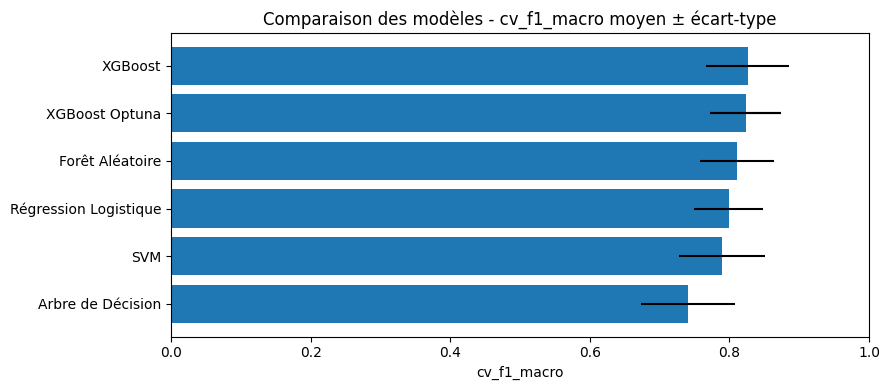

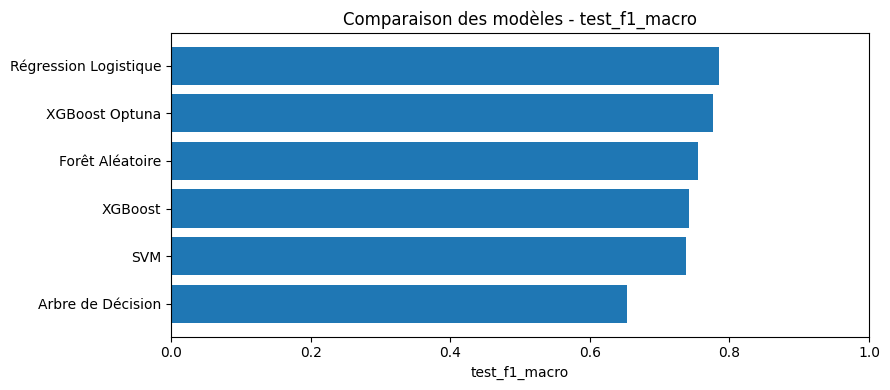

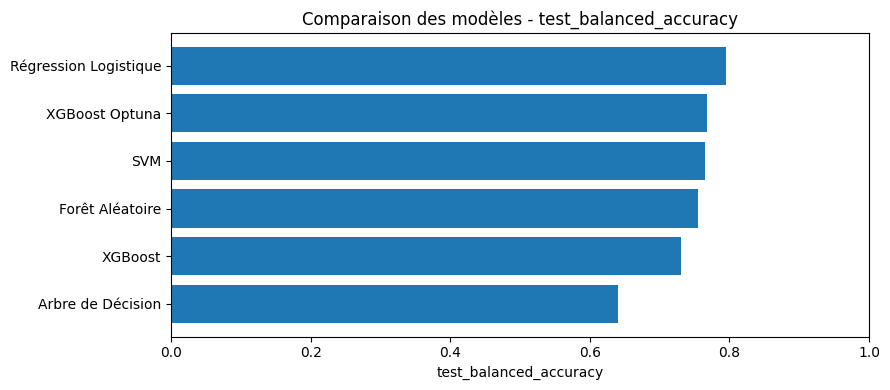

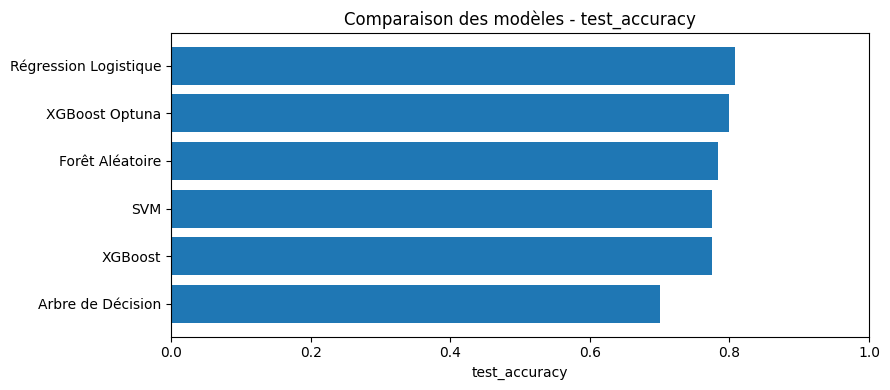

In [21]:
for metric in ["cv_f1_macro", "test_f1_macro", "test_balanced_accuracy", "test_accuracy"]:
    plot_df = comparison_df.sort_values(metric, ascending=True)
    plt.figure(figsize=(9, max(4, 0.45 * len(plot_df))))
    if metric == "cv_f1_macro" and "cv_f1_macro_std" in plot_df.columns:
        plt.barh(plot_df["model"], plot_df[metric], xerr=plot_df["cv_f1_macro_std"].fillna(0))
        plt.title(f"Comparaison des modèles - {metric} moyen ± écart-type")
    else:
        plt.barh(plot_df["model"], plot_df[metric])
        plt.title(f"Comparaison des modèles - {metric}")
    plt.xlabel(metric)
    plt.xlim(0, 1)
    plt.tight_layout()
    plt.show()

## 19. ⚖️ Impact de SMOTE sur les meilleurs modèles

Le jeu de données est déséquilibré : certaines classes sont beaucoup moins représentées que d'autres. Cela peut pousser un modèle à favoriser les classes majoritaires.

**SMOTE** crée artificiellement de nouveaux exemples pour les classes minoritaires en interpolant entre des observations proches. Son intérêt est de donner plus de poids aux classes rares pendant l'entraînement.

Attention :

- SMOTE doit être appliqué **uniquement sur les données d'entraînement** ;
- il ne faut jamais appliquer SMOTE sur `X_test` ni sur la feuille `Validation` ;
- dans ce notebook, SMOTE est placé à l'intérieur d'un `Pipeline`, donc il est appliqué correctement dans chaque fold de validation croisée ;
- comme les variables catégorielles sont encodées avant SMOTE, cette partie est utile comme expérience comparative, mais elle doit être interprétée avec prudence ;
- si SMOTE améliore le F1-macro sans dégrader fortement l'accuracy, il peut être intéressant pour mieux reconnaître les classes rares.


In [22]:
try:
    from imblearn.pipeline import Pipeline as ImbPipeline
    from imblearn.over_sampling import SMOTE, SMOTENC, RandomOverSampler
    IMBLEARN_AVAILABLE = True
except ImportError:
    IMBLEARN_AVAILABLE = False
    print("imbalanced-learn n'est pas installé. La partie SMOTE/SMOTENC est ignorée.")


def build_smote_nc_pipeline(X_reference: pd.DataFrame, classifier: Any) -> Any:
    """Pipeline anti-fuite : imputation/ordinal -> SMOTENC -> scaling/one-hot -> modèle.

    Pourquoi SMOTENC ? Parce que SMOTE appliqué après OneHotEncoder peut créer des valeurs artificielles
    comme 0.35 sur une modalité catégorielle. SMOTENC respecte mieux les colonnes catégorielles.
    """
    numeric_cols, categorical_cols = split_columns(X_reference)
    n_num = len(numeric_cols)
    n_cat = len(categorical_cols)

    initial_transformers = []
    if n_num:
        initial_transformers.append(("num", SimpleImputer(strategy="median"), numeric_cols))
    if n_cat:
        cat_initial = Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("ordinal", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
        ])
        initial_transformers.append(("cat", cat_initial, categorical_cols))

    initial_preprocessor = ColumnTransformer(initial_transformers, remainder="drop")
    categorical_indices = list(range(n_num, n_num + n_cat))

    if n_cat:
        sampler = SMOTENC(categorical_features=categorical_indices, random_state=RANDOM_STATE, k_neighbors=3)
    else:
        sampler = SMOTE(random_state=RANDOM_STATE, k_neighbors=3)

    post_transformers = []
    if n_num:
        post_transformers.append(("num", StandardScaler(), list(range(n_num))))
    if n_cat:
        post_transformers.append(("cat", make_one_hot_encoder(), categorical_indices))

    postprocessor = ColumnTransformer(post_transformers, remainder="drop")

    return ImbPipeline([
        ("initial", initial_preprocessor),
        ("sampler", sampler),
        ("postprocess", postprocessor),
        ("clf", classifier),
    ])


smote_results_rows = []

if RUN_SMOTE and IMBLEARN_AVAILABLE:
    smote_specs = [
        (
            "SMOTENC + Régression Logistique",
            LogisticRegression(max_iter=10000, random_state=RANDOM_STATE),
            {
                "clf__C": loguniform(1e-4, 1e4),
                "clf__solver": ["lbfgs", "newton-cg", "saga"],
            },
        ),
        (
            "SMOTENC + Forêt Aléatoire",
            RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=1),
            {
                "clf__n_estimators": randint(200, 900),
                "clf__criterion": ["gini", "entropy"],
                "clf__max_depth": [None, 4, 6, 8, 10, 12, 16, 20, 30],
                "clf__min_samples_split": randint(2, 40),
                "clf__min_samples_leaf": randint(1, 20),
                "clf__max_features": ["sqrt", "log2", 0.3, 0.5, 0.7, None],
                "clf__bootstrap": [True, False],
            },
        ),
        (
            "SMOTENC + SVM",
            SVC(random_state=RANDOM_STATE, cache_size=1000, probability=True),
            [
                {
                    "clf__kernel": ["rbf"],
                    "clf__C": loguniform(1e-3, 1e3),
                    "clf__gamma": loguniform(1e-5, 1e1),
                },
                {
                    "clf__kernel": ["linear"],
                    "clf__C": loguniform(1e-3, 1e2),
                },
            ],
        ),
    ]

    for name, classifier, param_dist in smote_specs:
        print()
        print(f"===== Recherche avec SMOTENC : {name} =====")

        smote_pipe = build_smote_nc_pipeline(X_train, classifier)

        smote_search = RandomizedSearchCV(
            smote_pipe,
            param_dist,
            n_iter=N_ITER_SMOTE,
            cv=cv,
            scoring=scorer,
            random_state=RANDOM_STATE,
            n_jobs=N_JOBS_SEARCH,
            refit=True,
            verbose=VERBOSE_SEARCH,
            return_train_score=True,
        )

        smote_search.fit(X_train, y_train)
        y_pred = smote_search.predict(X_test)

        add_result_row(
            name=name,
            estimator=smote_search.best_estimator_,
            y_pred=y_pred,
            cv_mean=smote_search.best_score_,
            cv_std=search_cv_std(smote_search),
            best_params=smote_search.best_params_,
            variant="Rééquilibrage SMOTENC + CV répétée",
            eligible_for_final=True,
            search=smote_search,
        )
        row = results_rows[-1]
        smote_results_rows.append(row)

        display(pd.DataFrame([row]).drop(columns=["best_params"]))
        print("Meilleurs paramètres :", smote_search.best_params_)
        print("Écart-type CV        :", round(search_cv_std(smote_search), 4))
        print(classification_report(y_test, y_pred, zero_division=0))

    smote_results_df = pd.DataFrame(smote_results_rows).sort_values("cv_f1_macro", ascending=False)
    comparison_df = build_comparison_df()
    comparison_df.to_csv(results_dir / "model_comparison.csv", index=False)
    comparison_df.to_csv(results_dir / "model_comparison_all.csv", index=False)

    best_model_name = get_best_eligible_model_name(comparison_df)
    best_search = fitted_models[best_model_name]["search"]

    print("Comparaison mise à jour avec les modèles SMOTENC :")
    display(comparison_df)
    print(f"Meilleur modèle après test SMOTENC : {best_model_name}")
else:
    smote_results_df = pd.DataFrame()
    print("SMOTENC ignoré. Pour l'activer : installer imbalanced-learn et vérifier RUN_SMOTE = True.")


===== Recherche avec SMOTENC : SMOTENC + Régression Logistique =====
Fitting 15 folds for each of 70 candidates, totalling 1050 fits


,model,variant,cv_f1_macro,cv_f1_macro_std,test_accuracy,test_balanced_accuracy,test_f1_macro,eligible_for_final
0,SMOTENC + Régression Logistique,Rééquilibrage SMOTENC + CV répétée,0.794612,0.05856,0.808333,0.823644,0.807731,True


Meilleurs paramètres : {'clf__C': np.float64(0.04005370050283179), 'clf__solver': 'lbfgs'}
Écart-type CV        : 0.0586
              precision    recall  f1-score   support

           1       0.90      0.90      0.90        39
           2       0.75      0.75      0.75         4
           3       0.86      1.00      0.92         6
           4       0.68      0.79      0.73        29
           5       0.73      0.85      0.79        13
           6       0.90      0.66      0.76        29

    accuracy                           0.81       120
   macro avg       0.80      0.82      0.81       120
weighted avg       0.82      0.81      0.81       120


===== Recherche avec SMOTENC : SMOTENC + Forêt Aléatoire =====
Fitting 15 folds for each of 70 candidates, totalling 1050 fits


,model,variant,cv_f1_macro,cv_f1_macro_std,test_accuracy,test_balanced_accuracy,test_f1_macro,eligible_for_final
0,SMOTENC + Forêt Aléatoire,Rééquilibrage SMOTENC + CV répétée,0.789433,0.044586,0.783333,0.792919,0.753465,True


Meilleurs paramètres : {'clf__bootstrap': True, 'clf__criterion': 'entropy', 'clf__max_depth': None, 'clf__max_features': 'log2', 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 13, 'clf__n_estimators': 652}
Écart-type CV        : 0.0446
              precision    recall  f1-score   support

           1       0.92      0.87      0.89        39
           2       0.60      0.75      0.67         4
           3       0.62      0.83      0.71         6
           4       0.68      0.72      0.70        29
           5       0.71      0.92      0.80        13
           6       0.86      0.66      0.75        29

    accuracy                           0.78       120
   macro avg       0.73      0.79      0.75       120
weighted avg       0.80      0.78      0.78       120


===== Recherche avec SMOTENC : SMOTENC + SVM =====
Fitting 15 folds for each of 70 candidates, totalling 1050 fits


,model,variant,cv_f1_macro,cv_f1_macro_std,test_accuracy,test_balanced_accuracy,test_f1_macro,eligible_for_final
0,SMOTENC + SVM,Rééquilibrage SMOTENC + CV répétée,0.782746,0.052138,0.816667,0.830865,0.812787,True


Meilleurs paramètres : {'clf__C': np.float64(0.02933870049164395), 'clf__kernel': 'linear'}
Écart-type CV        : 0.0521
              precision    recall  f1-score   support

           1       0.89      0.87      0.88        39
           2       0.75      0.75      0.75         4
           3       0.86      1.00      0.92         6
           4       0.71      0.83      0.76        29
           5       0.69      0.85      0.76        13
           6       0.95      0.69      0.80        29

    accuracy                           0.82       120
   macro avg       0.81      0.83      0.81       120
weighted avg       0.83      0.82      0.82       120

Comparaison mise à jour avec les modèles SMOTENC :


,model,variant,cv_f1_macro,cv_f1_macro_std,test_accuracy,test_balanced_accuracy,test_f1_macro,best_params,eligible_for_final
0,XGBoost,Recherche hyperparamètres + CV répétée,0.826268,0.059532,0.775000,0.730696,0.741696,"{""clf__colsample_bytree"": 0.7515681292900438, ...",True
1,XGBoost Optuna,Optimisation bayésienne + CV répétée,0.823018,0.050649,0.800000,0.768494,0.776325,"{""colsample_bytree"": 0.8141106740609885, ""gamm...",True
2,XGBoost Optuna,Optimisation bayésienne + CV répétée,0.823018,0.050649,0.800000,0.768494,0.776325,"{""colsample_bytree"": 0.8141106740609885, ""gamm...",True
3,Forêt Aléatoire,Recherche hyperparamètres + CV répétée,0.810818,0.053208,0.783333,0.755526,0.755576,"{""clf__bootstrap"": true, ""clf__class_weight"": ...",True
4,Régression Logistique,Recherche hyperparamètres + CV répétée,0.798731,0.048999,0.808333,0.794798,0.784447,"{""clf__C"": 1.0, ""clf__class_weight"": null, ""cl...",True
5,SMOTENC + Régression Logistique,Rééquilibrage SMOTENC + CV répétée,0.794612,0.058560,0.808333,0.823644,0.807731,"{""clf__C"": 0.04005370050283179, ""clf__solver"":...",True
6,SVM,Recherche hyperparamètres + CV répétée,0.789615,0.061760,0.775000,0.765141,0.737318,"{""clf__C"": 78.42676320619432, ""clf__class_weig...",True
7,SMOTENC + Forêt Aléatoire,Rééquilibrage SMOTENC + CV répétée,0.789433,0.044586,0.783333,0.792919,0.753465,"{""clf__bootstrap"": true, ""clf__criterion"": ""en...",True
8,SMOTENC + SVM,Rééquilibrage SMOTENC + CV répétée,0.782746,0.052138,0.816667,0.830865,0.812787,"{""clf__C"": 0.02933870049164395, ""clf__kernel"":...",True
9,Arbre de Décision,Recherche hyperparamètres + CV répétée,0.741142,0.067316,0.700000,0.640399,0.652694,"{""clf__ccp_alpha"": 0.001, ""clf__class_weight"":...",True


Meilleur modèle après test SMOTENC : XGBoost


## 20. 📈 Visualisation de l'impact de SMOTE

Cette visualisation compare les modèles avec SMOTE aux modèles standards. L'objectif n'est pas seulement d'augmenter l'accuracy, mais surtout de voir si SMOTE améliore le **F1-macro**, qui donne plus d'importance aux classes minoritaires.

Interprétation :

- si le F1-macro augmente, SMOTE aide probablement les classes rares ;
- si l'accuracy baisse beaucoup, SMOTE crée peut-être trop de faux positifs ;
- si SMOTE ne change presque rien, les modèles avec `class_weight="balanced"` ou les modèles d'arbres suffisent peut-être.


,model,variant,cv_f1_macro,cv_f1_macro_std,test_accuracy,test_balanced_accuracy,test_f1_macro,best_params,eligible_for_final
0,SMOTENC + Régression Logistique,Rééquilibrage SMOTENC + CV répétée,0.794612,0.058560,0.808333,0.823644,0.807731,"{""clf__C"": 0.04005370050283179, ""clf__solver"":...",True
1,SMOTENC + Forêt Aléatoire,Rééquilibrage SMOTENC + CV répétée,0.789433,0.044586,0.783333,0.792919,0.753465,"{""clf__bootstrap"": true, ""clf__criterion"": ""en...",True
2,SMOTENC + SVM,Rééquilibrage SMOTENC + CV répétée,0.782746,0.052138,0.816667,0.830865,0.812787,"{""clf__C"": 0.02933870049164395, ""clf__kernel"":...",True


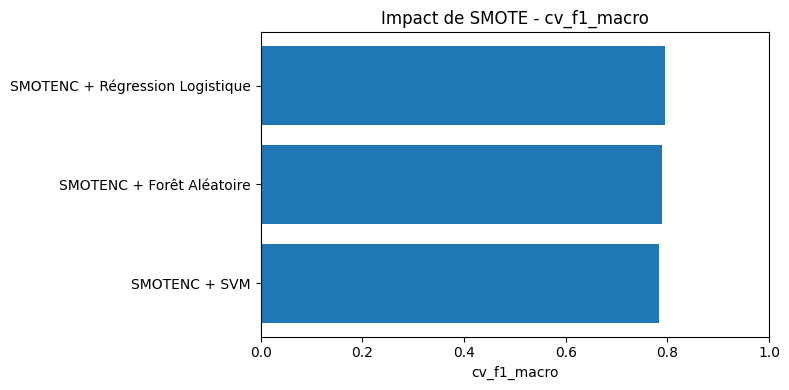

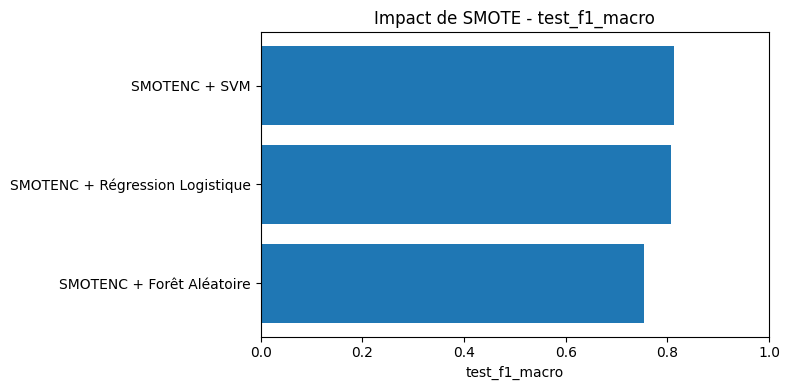

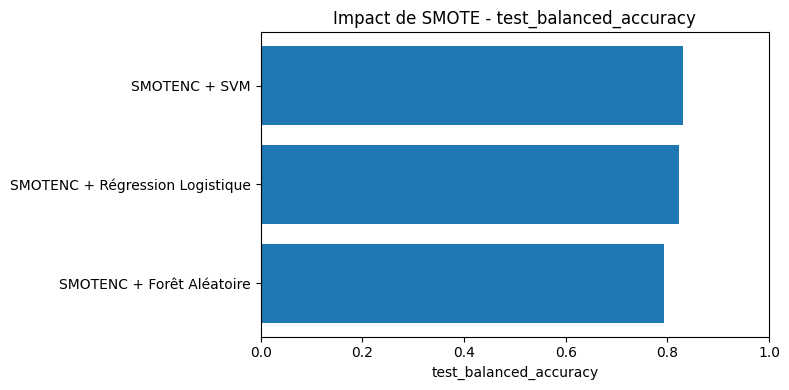

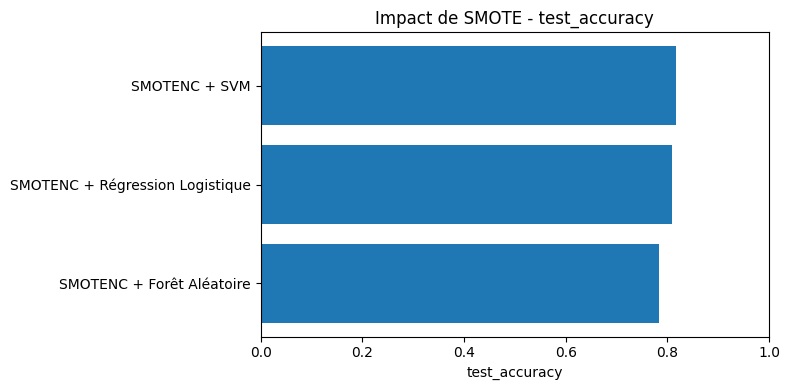

In [23]:
if "smote_results_df" in globals() and not smote_results_df.empty:
    display(smote_results_df)

    smote_plot_df = comparison_df[comparison_df["model"].str.contains("SMOTE", regex=False)].copy()

    for metric in ["cv_f1_macro", "test_f1_macro", "test_balanced_accuracy", "test_accuracy"]:
        plot_df = smote_plot_df.sort_values(metric, ascending=True)
        plt.figure(figsize=(8, 4))
        plt.barh(plot_df["model"], plot_df[metric])
        plt.title(f"Impact de SMOTE - {metric}")
        plt.xlabel(metric)
        plt.xlim(0, 1)
        plt.tight_layout()
        plt.show()
else:
    print("Aucun résultat SMOTE à visualiser.")


## 21. 📊 Courbes ROC multiclasses, One-vs-Rest

Les courbes ROC sont plus connues pour la classification binaire. En multiclasse, on utilise souvent l'approche **One-vs-Rest** : pour chaque classe, on transforme temporairement le problème en :

> classe étudiée contre toutes les autres classes.

Cette visualisation répond à une question différente de l'accuracy : elle mesure la capacité du modèle à **séparer une classe des autres** à partir de ses scores ou probabilités.

À retenir :

- une AUC proche de `1` indique une bonne séparation ;
- une AUC proche de `0.5` indique une séparation faible, proche du hasard ;
- la ROC ne remplace pas le F1-macro, surtout quand les classes sont déséquilibrées ;
- ici, elle complète l'analyse pour comprendre quelles classes sont faciles ou difficiles à distinguer.


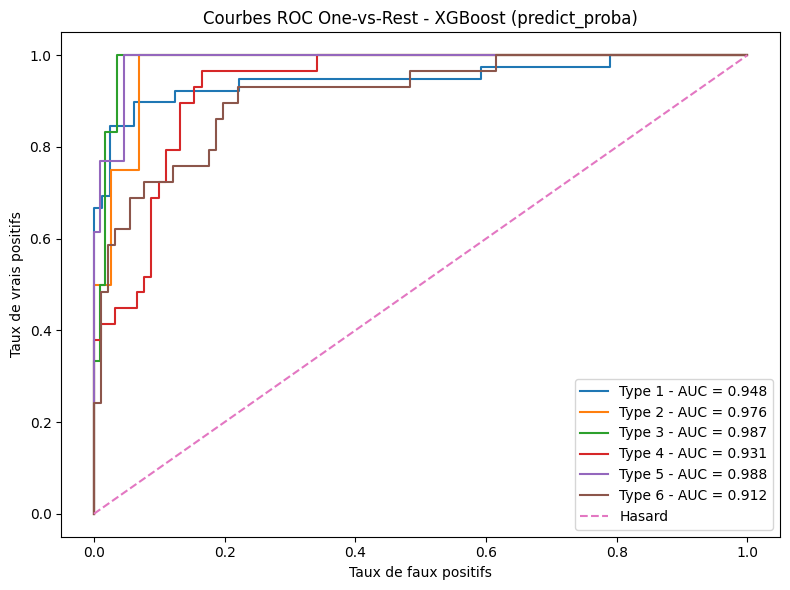

AUC macro moyenne : 0.9571
AUC micro moyenne : 0.9581


,Type,AUC_ROC_One_vs_Rest
4,5,0.987779
2,3,0.986842
1,2,0.976293
0,1,0.948401
3,4,0.931034
5,6,0.912088


In [24]:
def get_model_scores(estimator, X_data):
    """Retourne des scores utilisables pour les courbes ROC."""
    if hasattr(estimator, "predict_proba"):
        return estimator.predict_proba(X_data), "predict_proba"
    if hasattr(estimator, "decision_function"):
        scores = estimator.decision_function(X_data)
        if scores.ndim == 1:
            scores = np.column_stack([-scores, scores])
        return scores, "decision_function"
    raise AttributeError("Ce modèle ne fournit ni predict_proba ni decision_function.")

roc_model_name = best_model_name
roc_estimator = fitted_models[roc_model_name]["best_estimator"]

try:
    y_score, score_source = get_model_scores(roc_estimator, X_test)
    roc_classes = np.array(roc_estimator.classes_)
    y_test_bin = label_binarize(y_test, classes=roc_classes)

    roc_auc_by_class = {}
    plt.figure(figsize=(8, 6))

    for i, class_label in enumerate(roc_classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        class_auc = auc(fpr, tpr)
        roc_auc_by_class[class_label] = class_auc
        plt.plot(fpr, tpr, label=f"Type {class_label} - AUC = {class_auc:.3f}")

    plt.plot([0, 1], [0, 1], linestyle="--", label="Hasard")
    plt.xlabel("Taux de faux positifs")
    plt.ylabel("Taux de vrais positifs")
    plt.title(f"Courbes ROC One-vs-Rest - {roc_model_name} ({score_source})")
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.show()

    roc_auc_macro = roc_auc_score(y_test_bin, y_score, average="macro")
    roc_auc_micro = roc_auc_score(y_test_bin, y_score, average="micro")

    roc_summary_df = pd.DataFrame({
        "Type": list(roc_auc_by_class.keys()),
        "AUC_ROC_One_vs_Rest": list(roc_auc_by_class.values()),
    })

    print(f"AUC macro moyenne : {roc_auc_macro:.4f}")
    print(f"AUC micro moyenne : {roc_auc_micro:.4f}")
    display(roc_summary_df.sort_values("AUC_ROC_One_vs_Rest", ascending=False))

except Exception as exc:
    roc_auc_macro = np.nan
    roc_auc_micro = np.nan
    print("Courbes ROC non disponibles pour ce modèle :", exc)


## 22. 🎯 Optimisation du seuil de décision

Par défaut, un modèle multiclasse choisit la classe avec la probabilité la plus élevée : c'est la règle de l'`argmax`.

L'optimisation du seuil modifie cette règle pour favoriser certaines classes. C'est surtout utile quand :

- certaines classes sont rares ;
- le F1-macro est plus important que l'accuracy globale ;
- confondre une classe minoritaire avec une classe majoritaire est problématique.

Méthode utilisée ici :

1. on choisit le meilleur modèle capable de produire des probabilités ;
2. on sépare une petite partie de `X_train` pour régler les seuils ;
3. on cherche des seuils par classe pour améliorer le F1-macro ;
4. on évalue ensuite ces seuils sur `X_test`.

Cette précaution est importante : si on optimisait les seuils directement sur `X_test`, le score final serait trop optimiste.


In [25]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import f1_score, classification_report
from sklearn.base import clone


if "RUN_THRESHOLD_OPTIMIZATION" not in globals():
    RUN_THRESHOLD_OPTIMIZATION = True

if "RANDOM_STATE" not in globals():
    RANDOM_STATE = 42


def predict_with_class_thresholds(proba: np.ndarray, classes: np.ndarray, thresholds: dict) -> np.ndarray:
    """
    Applique des seuils par classe.

    Un seuil plus petit favorise une classe.
    Un seuil plus grand pénalise une classe.
    """
    threshold_array = np.array(
        [thresholds.get(cls, 1.0) for cls in classes],
        dtype=float
    )

    adjusted_scores = proba / threshold_array
    return classes[np.argmax(adjusted_scores, axis=1)]


def has_predict_proba(estimator) -> bool:
    return callable(getattr(estimator, "predict_proba", None))


def make_calibrated_classifier(estimator):
    """
    Compatible avec plusieurs versions de scikit-learn.
    """
    try:
        return CalibratedClassifierCV(
            estimator=clone(estimator),
            method="sigmoid",
            cv=3
        )
    except TypeError:
        return CalibratedClassifierCV(
            base_estimator=clone(estimator),
            method="sigmoid",
            cv=3
        )


threshold_results_df = pd.DataFrame()

if RUN_THRESHOLD_OPTIMIZATION:
    try:
        comparison_df = build_comparison_df()

        # On exclut XGBoost de la calibration car il peut être mal reconnu
        # par CalibratedClassifierCV dans certains pipelines.
        proba_candidate_names = [
            model_name
            for model_name in comparison_df.loc[
                comparison_df["eligible_for_final"] == True,
                "model"
            ]
            if model_name in fitted_models
            and has_predict_proba(fitted_models[model_name]["best_estimator"])
            and "xgboost" not in model_name.lower()
        ]

        if not proba_candidate_names:
            print("Aucun modèle compatible avec predict_proba disponible pour les seuils.")

        else:
            print("Modèles candidats pour calibration et seuils :")
            print(proba_candidate_names)

            X_fit_threshold, X_tune_threshold, y_fit_threshold, y_tune_threshold = train_test_split(
                X_train,
                y_train,
                test_size=0.25,
                stratify=y_train,
                random_state=RANDOM_STATE
            )

            calibrated_estimator = None
            base_threshold_estimator = None
            threshold_model_name = None

            # On essaye les modèles un par un
            for candidate_name in proba_candidate_names:
                candidate_estimator = fitted_models[candidate_name]["best_estimator"]

                print(f"\nTentative de calibration pour : {candidate_name}")

                try:
                    candidate_calibrated = make_calibrated_classifier(candidate_estimator)
                    candidate_calibrated.fit(X_fit_threshold, y_fit_threshold)

                    calibrated_estimator = candidate_calibrated
                    base_threshold_estimator = candidate_estimator
                    threshold_model_name = candidate_name

                    print(f"Calibration réussie pour : {candidate_name}")
                    break

                except Exception as err:
                    print(f"Calibration impossible pour {candidate_name}.")
                    print(f"Raison : {err}")
                    print("Passage au modèle suivant.")

            if calibrated_estimator is None:
                raise RuntimeError(
                    "Aucun modèle compatible avec CalibratedClassifierCV. "
                    "Utilise LogisticRegression, RandomForest ou SVM avec probability=True."
                )

            print(f"\nModèle finalement utilisé pour calibration et seuils : {threshold_model_name}")

            threshold_classes = np.array(calibrated_estimator.classes_)

            tune_proba = calibrated_estimator.predict_proba(X_tune_threshold)
            default_tune_pred = calibrated_estimator.predict(X_tune_threshold)

            best_threshold_score = f1_score(
                y_tune_threshold,
                default_tune_pred,
                average="macro",
                zero_division=0
            )

            best_thresholds = {
                cls: 1.0
                for cls in threshold_classes
            }

            threshold_grid = np.round(np.linspace(0.35, 1.50, 24), 3)

            for _ in range(4):
                improved = False

                for cls in threshold_classes:
                    local_best_score = best_threshold_score
                    local_best_threshold = best_thresholds[cls]

                    for val in threshold_grid:
                        candidate_thresholds = best_thresholds.copy()
                        candidate_thresholds[cls] = val

                        candidate_pred = predict_with_class_thresholds(
                            tune_proba,
                            threshold_classes,
                            candidate_thresholds
                        )

                        candidate_score = f1_score(
                            y_tune_threshold,
                            candidate_pred,
                            average="macro",
                            zero_division=0
                        )

                        if candidate_score > local_best_score:
                            local_best_score = candidate_score
                            local_best_threshold = val

                    if local_best_score > best_threshold_score + 1e-6:
                        best_thresholds[cls] = local_best_threshold
                        best_threshold_score = local_best_score
                        improved = True

                if not improved:
                    break

            print("\nSeuils optimisés par classe :")
            for cls, threshold in best_thresholds.items():
                print(f"Classe {cls} : seuil = {threshold}")

            calibrated_test_estimator = make_calibrated_classifier(base_threshold_estimator)
            calibrated_test_estimator.fit(X_train, y_train)

            test_classes = np.array(calibrated_test_estimator.classes_)

            default_test_pred = calibrated_test_estimator.predict(X_test)
            test_proba = calibrated_test_estimator.predict_proba(X_test)

            threshold_test_pred = predict_with_class_thresholds(
                test_proba,
                test_classes,
                best_thresholds
            )

            threshold_results_df = pd.DataFrame(
                [
                    {
                        "méthode": "Argmax classique calibré",
                        "modèle": threshold_model_name,
                        "test_f1_macro": f1_score(
                            y_test,
                            default_test_pred,
                            average="macro",
                            zero_division=0
                        ),
                    },
                    {
                        "méthode": "Seuils optimisés calibrés",
                        "modèle": threshold_model_name,
                        "test_f1_macro": f1_score(
                            y_test,
                            threshold_test_pred,
                            average="macro",
                            zero_division=0
                        ),
                    },
                ]
            )

            display(threshold_results_df)

            print("\nRapport de classification avec seuils optimisés :")
            print(
                classification_report(
                    y_test,
                    threshold_test_pred,
                    zero_division=0
                )
            )

    except Exception as e:
        print(f"Erreur lors de l'optimisation : {e}")

else:
    print("Optimisation des seuils désactivée.")

Modèles candidats pour calibration et seuils :
['Forêt Aléatoire', 'Régression Logistique', 'SMOTENC + Régression Logistique', 'SMOTENC + Forêt Aléatoire', 'SMOTENC + SVM', 'Arbre de Décision']

Tentative de calibration pour : Forêt Aléatoire
Calibration réussie pour : Forêt Aléatoire

Modèle finalement utilisé pour calibration et seuils : Forêt Aléatoire

Seuils optimisés par classe :
Classe 1 : seuil = 1.0
Classe 2 : seuil = 0.4
Classe 3 : seuil = 1.0
Classe 4 : seuil = 1.1
Classe 5 : seuil = 0.6
Classe 6 : seuil = 0.5


,méthode,modèle,test_f1_macro
0,Argmax classique calibré,Forêt Aléatoire,0.776866
1,Seuils optimisés calibrés,Forêt Aléatoire,0.732612



Rapport de classification avec seuils optimisés :
              precision    recall  f1-score   support

           1       0.92      0.90      0.91        39
           2       0.67      0.50      0.57         4
           3       0.80      0.67      0.73         6
           4       0.69      0.62      0.65        29
           5       0.71      0.92      0.80        13
           6       0.71      0.76      0.73        29

    accuracy                           0.78       120
   macro avg       0.75      0.73      0.73       120
weighted avg       0.78      0.78      0.77       120



## 23. 📈 Visualisation de l'impact du seuil de décision

Cette partie permet de voir si le réglage des seuils améliore réellement le modèle sur le jeu de test.

Il faut interpréter les résultats avec nuance :

- une hausse du F1-macro est intéressante si l'objectif est de mieux traiter les classes rares ;
- une baisse de l'accuracy peut être acceptable si elle améliore nettement les classes minoritaires ;
- si les seuils n'améliorent rien, il vaut mieux garder la règle classique de l'argmax.


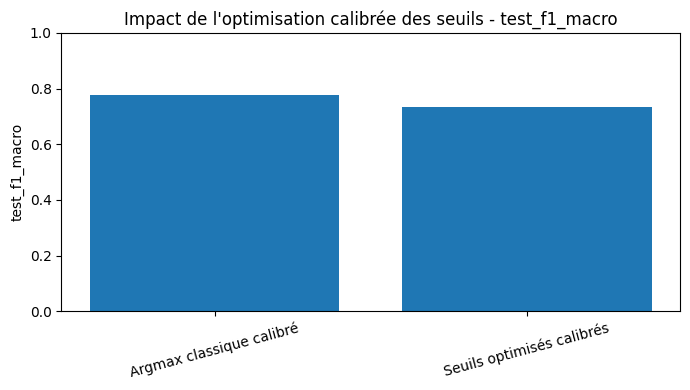

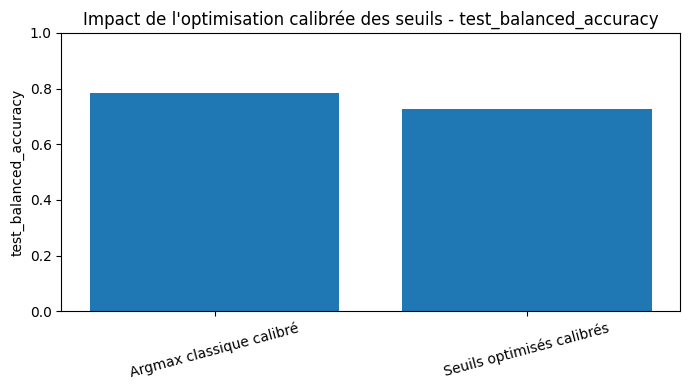

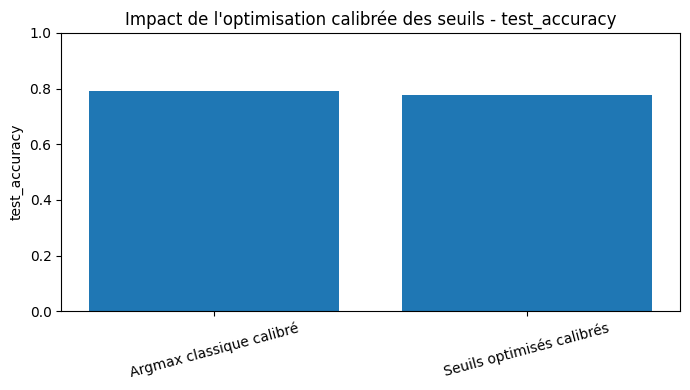

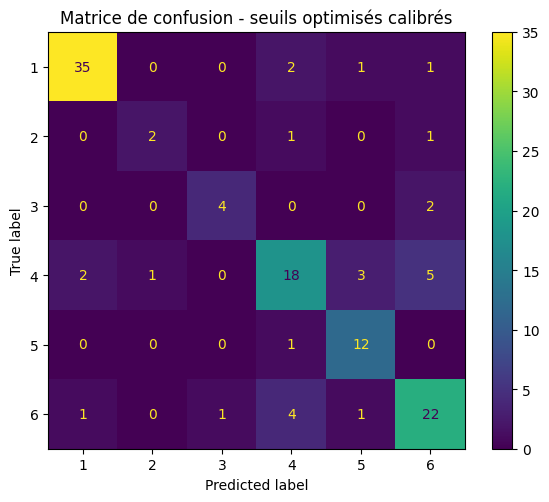

In [26]:
from sklearn.metrics import balanced_accuracy_score, accuracy_score

if "threshold_results_df" in globals() and not threshold_results_df.empty:
    # Correction : Calcul des métriques manquantes pour la visualisation
    if "test_balanced_accuracy" not in threshold_results_df.columns:
        threshold_results_df["test_balanced_accuracy"] = [
            balanced_accuracy_score(y_test, default_test_pred),
            balanced_accuracy_score(y_test, threshold_test_pred)
        ]
    if "test_accuracy" not in threshold_results_df.columns:
        threshold_results_df["test_accuracy"] = [
            accuracy_score(y_test, default_test_pred),
            accuracy_score(y_test, threshold_test_pred)
        ]

    for metric in ["test_f1_macro", "test_balanced_accuracy", "test_accuracy"]:
        plt.figure(figsize=(7, 4))
        plt.bar(threshold_results_df["méthode"], threshold_results_df[metric])
        plt.title(f"Impact de l'optimisation calibrée des seuils - {metric}")
        plt.ylabel(metric)
        plt.ylim(0, 1)
        plt.xticks(rotation=15)
        plt.tight_layout()
        plt.show()

    plot_confusion(y_test, threshold_test_pred, "Matrice de confusion - seuils optimisés calibrés")
else:
    print("Aucun résultat de seuil à visualiser.")

## 24. 🔍 Analyse détaillée des erreurs

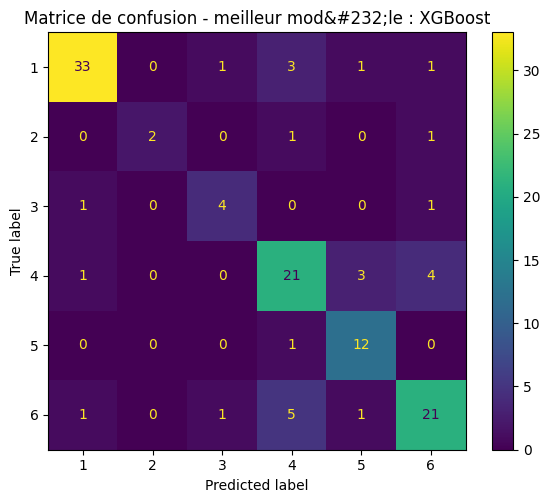

Nombre total d'erreurs : 27
Taux d'erreur : 0.225


,nb_erreurs,effectif,taux_erreur
true_Type,,,
1,6,39,0.153846
2,2,4,0.500000
3,2,6,0.333333
4,8,29,0.275862
5,1,13,0.076923
6,8,29,0.275862


,age,marqueur 2,marqueur 3,marqueur 4,marqueur 5,marqueur 6,marqueur 7,marqueur 8,marqueur 9,true_Type,predicted_Type,is_error
246,71.0,NEG,NEG,NEG,POS,460.0,1670.0,2650.0,16230.0,4,6,True
493,83.0,POS,NEG,NEG,POS,860.0,1050.0,5120.0,26590.0,1,4,True
204,77.0,NEG,NEG,NEG,POS,930.0,570.0,1100.0,20010.0,6,4,True
589,37.0,POS,NEG,POS,POS,1200.0,1420.0,100.0,30980.0,1,5,True
511,69.0,POS,NEG,POS,POS,1040.0,1010.0,3060.0,6410.0,6,1,True
552,59.0,POS,NEG,POS,POS,1030.0,2050.0,8750.0,43720.0,1,3,True
53,82.0,POS,NEG,NEG,NEG,930.0,540.0,210.0,17300.0,4,5,True
70,56.0,NEG,NEG,NEG,POS,1520.0,360.0,100.0,27980.0,5,4,True
449,68.0,NEG,NEG,NEG,POS,1120.0,270.0,80.0,16980.0,4,5,True
1,81.0,NEG,NEG,NEG,POS,970.0,1800.0,310.0,19500.0,4,6,True


In [27]:
try:
    best_y_pred = fitted_models[best_model_name]["y_pred"]
    plot_confusion(y_test, best_y_pred, f"Matrice de confusion - meilleur mod&#232;le : {best_model_name}")

    errors_df = X_test.copy()
    errors_df["true_Type"] = y_test.values
    errors_df["predicted_Type"] = best_y_pred
    errors_df["is_error"] = errors_df["true_Type"] != errors_df["predicted_Type"]

    print("Nombre total d'erreurs :", int(errors_df["is_error"].sum()))
    print("Taux d'erreur :", round(errors_df["is_error"].mean(), 4))

    errors_by_class = (
        errors_df.groupby("true_Type")["is_error"]
        .agg(["sum", "count", "mean"])
        .rename(columns={"sum": "nb_erreurs", "count": "effectif", "mean": "taux_erreur"})
    )
    display(errors_by_class)
    display(errors_df[errors_df["is_error"]].head(20))
except NameError:
    print("Erreur : Les mod&#232;les n'ont pas &#233;t&#233; entra&#238;n&#233;s dans cette session. Veuillez r&#233;-ex&#233;cuter les sections 8 &#224; 17.")

## 25. 📊 Visualisation des erreurs par variable

<Figure size 700x400 with 0 Axes>

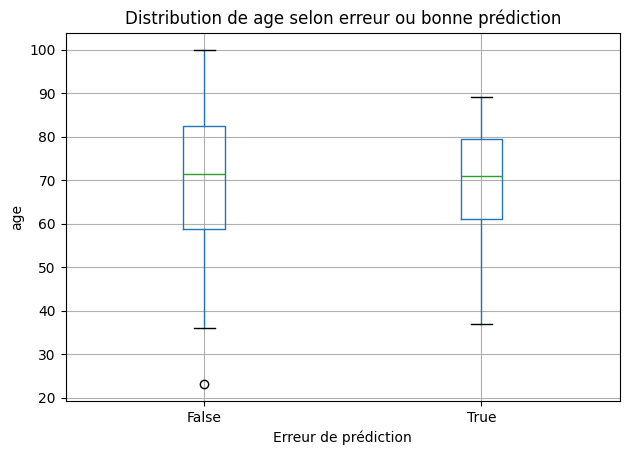

<Figure size 700x400 with 0 Axes>

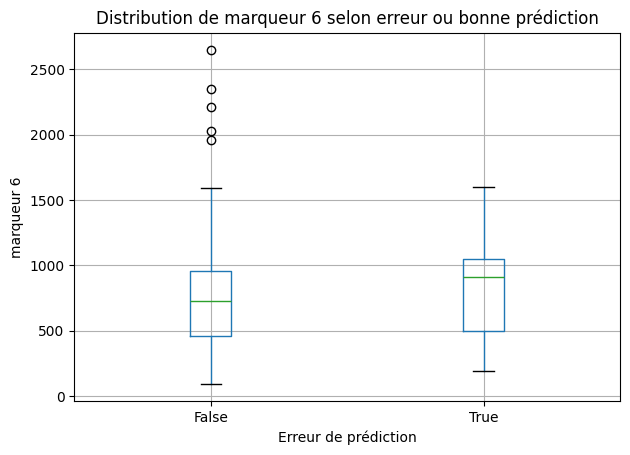

<Figure size 700x400 with 0 Axes>

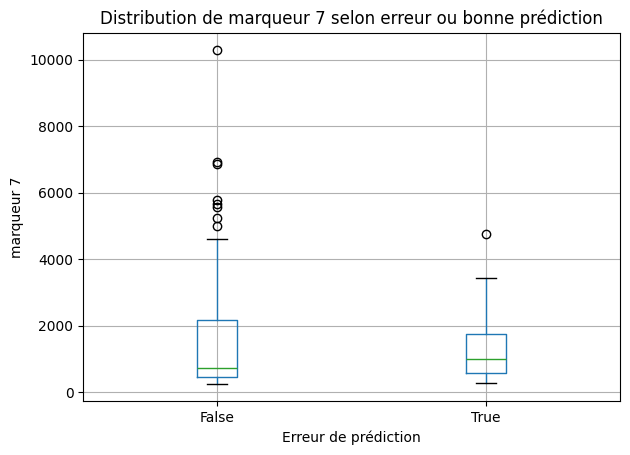

<Figure size 700x400 with 0 Axes>

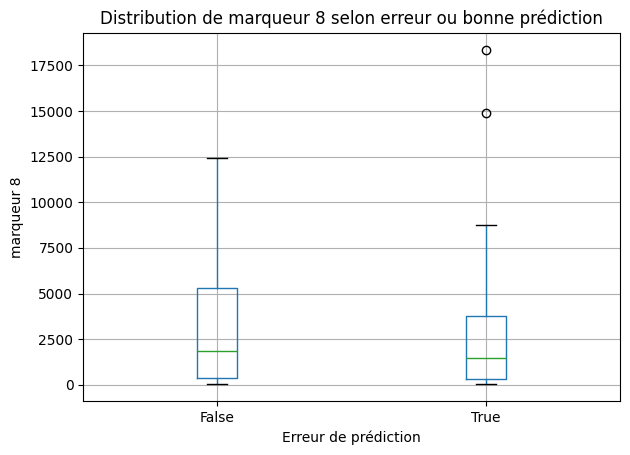

<Figure size 700x400 with 0 Axes>

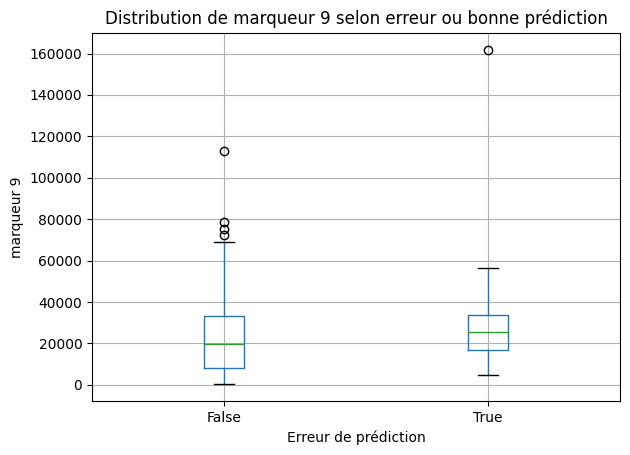

In [28]:
try:
    numeric_cols = X_test.select_dtypes(include=[np.number]).columns.tolist()

    for col in numeric_cols[:6]:
        plt.figure(figsize=(7, 4))
        errors_df.boxplot(column=col, by="is_error")
        plt.title(f"Distribution de {col} selon erreur ou bonne prédiction")
        plt.suptitle("")
        plt.xlabel("Erreur de prédiction")
        plt.ylabel(col)
        plt.tight_layout()
        plt.show()
except NameError as e:
    print(f"Erreur de dépendance : {e}.")
    print("Veuillez vous assurer d'avoir exécuté la Section 6 (X_test) et la Section 24 (errors_df) avant cette cellule.")

## 26. ✅ Résumé final et recommandations

In [29]:
comparison_df = build_comparison_df()
comparison_df.to_csv(results_dir / "model_comparison.csv", index=False)
comparison_df.to_csv(results_dir / "model_comparison_all.csv", index=False)

best_model_name = get_best_eligible_model_name(comparison_df)
best_row = comparison_df[comparison_df["model"] == best_model_name].iloc[0]

advanced_notes = []

if "roc_auc_macro" in globals() and not pd.isna(roc_auc_macro):
    advanced_notes.append(f"- ROC multiclasse : AUC macro = {roc_auc_macro:.4f}, AUC micro = {roc_auc_micro:.4f}.")

if "smote_results_df" in globals() and not smote_results_df.empty:
    best_smote_row = smote_results_df.sort_values("cv_f1_macro", ascending=False).iloc[0]
    advanced_notes.append(
        f"- SMOTENC : meilleur essai = {best_smote_row['model']} avec F1-macro CV = {best_smote_row['cv_f1_macro']:.4f} ± {best_smote_row.get('cv_f1_macro_std', np.nan):.4f}."
    )

if "threshold_results_df" in globals() and not threshold_results_df.empty:
    default_f1 = threshold_results_df.iloc[0]["test_f1_macro"]
    threshold_f1 = threshold_results_df.iloc[1]["test_f1_macro"]
    advanced_notes.append(
        f"- Seuils calibrés : F1-macro test argmax = {default_f1:.4f}, F1-macro test seuils = {threshold_f1:.4f}."
    )

advanced_text = "\n".join(advanced_notes) if advanced_notes else "- Les modules avancés n'ont pas été exécutés ou ne sont pas disponibles."

summary = f"""
Résumé final
============

Nombre d'observations d'entraînement : {len(train_df)}
Nombre d'observations à prédire : {len(X_validation)}
Nombre de classes : {y.nunique()}
Classes : {sorted(y.unique())}

Meilleur modèle selon la validation croisée répétée : {best_model_name}
Variante : {fitted_models[best_model_name].get('variant', '')}
F1-macro CV : {best_row['cv_f1_macro']:.4f}
Écart-type CV : {best_row['cv_f1_macro_std']:.4f}
F1-macro test : {best_row['test_f1_macro']:.4f}
Balanced accuracy test : {best_row['test_balanced_accuracy']:.4f}
Accuracy test : {best_row['test_accuracy']:.4f}

Modules avancés :
{advanced_text}

Recommandations :
- utiliser F1-macro comme métrique principale, car les classes sont déséquilibrées ;
- choisir le modèle selon la validation croisée répétée, pas selon un seul split test ;
- regarder l'écart-type CV : un modèle légèrement moins bon mais plus stable peut être préférable ;
- utiliser SMOTENC comme comparaison contrôlée, jamais sur le test ni sur la validation finale ;
- garder Optuna comme optimisation avancée si le temps de calcul le permet ;
- interpréter les seuils calibrés comme une analyse avancée, pas automatiquement comme modèle final ;
- utiliser l'analyse des erreurs pour expliquer les limites du modèle.
"""
print(summary)

display(comparison_df)


Résumé final

Nombre d'observations d'entraînement : 598
Nombre d'observations à prédire : 75
Nombre de classes : 6
Classes : [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]

Meilleur modèle selon la validation croisée répétée : XGBoost
Variante : Recherche hyperparamètres + CV répétée
F1-macro CV : 0.8263
Écart-type CV : 0.0595
F1-macro test : 0.7417
Balanced accuracy test : 0.7307
Accuracy test : 0.7750

Modules avancés :
- ROC multiclasse : AUC macro = 0.9571, AUC micro = 0.9581.
- SMOTENC : meilleur essai = SMOTENC + Régression Logistique avec F1-macro CV = 0.7946 ± 0.0586.
- Seuils calibrés : F1-macro test argmax = 0.7769, F1-macro test seuils = 0.7326.

Recommandations :
- utiliser F1-macro comme métrique principale, car les classes sont déséquilibrées ;
- choisir le modèle selon la validation croisée répétée, pas selon un seul split test ;
- regarder l'écart-type CV : un modèle légèrement moins bon mais plus stable peut être préférable ;
- utilise

,model,variant,cv_f1_macro,cv_f1_macro_std,test_accuracy,test_balanced_accuracy,test_f1_macro,best_params,eligible_for_final
0,XGBoost,Recherche hyperparamètres + CV répétée,0.826268,0.059532,0.775000,0.730696,0.741696,"{""clf__colsample_bytree"": 0.7515681292900438, ...",True
1,XGBoost Optuna,Optimisation bayésienne + CV répétée,0.823018,0.050649,0.800000,0.768494,0.776325,"{""colsample_bytree"": 0.8141106740609885, ""gamm...",True
2,XGBoost Optuna,Optimisation bayésienne + CV répétée,0.823018,0.050649,0.800000,0.768494,0.776325,"{""colsample_bytree"": 0.8141106740609885, ""gamm...",True
3,Forêt Aléatoire,Recherche hyperparamètres + CV répétée,0.810818,0.053208,0.783333,0.755526,0.755576,"{""clf__bootstrap"": true, ""clf__class_weight"": ...",True
4,Régression Logistique,Recherche hyperparamètres + CV répétée,0.798731,0.048999,0.808333,0.794798,0.784447,"{""clf__C"": 1.0, ""clf__class_weight"": null, ""cl...",True
5,SMOTENC + Régression Logistique,Rééquilibrage SMOTENC + CV répétée,0.794612,0.058560,0.808333,0.823644,0.807731,"{""clf__C"": 0.04005370050283179, ""clf__solver"":...",True
6,SVM,Recherche hyperparamètres + CV répétée,0.789615,0.061760,0.775000,0.765141,0.737318,"{""clf__C"": 78.42676320619432, ""clf__class_weig...",True
7,SMOTENC + Forêt Aléatoire,Rééquilibrage SMOTENC + CV répétée,0.789433,0.044586,0.783333,0.792919,0.753465,"{""clf__bootstrap"": true, ""clf__criterion"": ""en...",True
8,SMOTENC + SVM,Rééquilibrage SMOTENC + CV répétée,0.782746,0.052138,0.816667,0.830865,0.812787,"{""clf__C"": 0.02933870049164395, ""clf__kernel"":...",True
9,Arbre de Décision,Recherche hyperparamètres + CV répétée,0.741142,0.067316,0.700000,0.640399,0.652694,"{""clf__ccp_alpha"": 0.001, ""clf__class_weight"":...",True


## 27. 📤 Génération du fichier de soumission

In [30]:
# Par défaut, on utilise le meilleur modèle éligible sélectionné par validation croisée répétée.
# Les seuils optimisés restent désactivés pour la soumission finale, sauf choix explicite et justifié.
USE_THRESHOLDS_FOR_SUBMISSION = False

comparison_df = build_comparison_df()
best_model_name = get_best_eligible_model_name(comparison_df)
best_estimator = fitted_models[best_model_name]["best_estimator"]

if USE_THRESHOLDS_FOR_SUBMISSION and "best_thresholds" in globals() and "base_threshold_estimator" in globals():
    final_model = clone(base_threshold_estimator)
    final_model.fit(X, y)
    validation_proba = final_model.predict_proba(X_validation)
    validation_predictions = predict_with_class_thresholds(
        validation_proba,
        np.array(final_model.classes_),
        best_thresholds,
    )
    print("Soumission générée avec seuils optimisés.")
else:
    final_model = clone(best_estimator)
    final_model.fit(X, y)
    validation_predictions = final_model.predict(X_validation)
    print(f"Soumission générée avec le meilleur modèle CV : {best_model_name}")

submission_df = pd.DataFrame({
    "Id": np.arange(1, len(validation_predictions) + 1),
    "Type": validation_predictions.astype(int),
})

submission_path = results_dir / "predictions_machine_learning.csv"
submission_df.to_csv(submission_path, index=False)

# Sauvegarde finale des résultats complets.
comparison_df.to_csv(results_dir / "model_comparison.csv", index=False)
comparison_df.to_csv(results_dir / "model_comparison_all.csv", index=False)

display(submission_df.head())
print(f"Fichier de soumission généré : {submission_path}")
print(f"Comparaison complète générée : {results_dir / 'model_comparison_all.csv'}")

Soumission générée avec le meilleur modèle CV : XGBoost


,Id,Type
0,1,3
1,2,2
2,3,4
3,4,1
4,5,3


Fichier de soumission généré : results/predictions_machine_learning.csv
Comparaison complète générée : results/model_comparison_all.csv


## 28. Conclusion générale

Ce notebook présente une démarche complète de classification supervisée pour prédire le type de cancer à partir des variables disponibles.

Plusieurs modèles ont été entraînés et comparés : Régression Logistique, Arbre de Décision, Forêt Aléatoire, SVM et XGBoost. La comparaison repose principalement sur le F1-score macro, car les classes sont déséquilibrées et l’accuracy seule pourrait donner une vision trop optimiste des performances.

La validation croisée répétée a permis d’obtenir une estimation plus robuste des performances, en tenant compte de la variabilité des découpages train/test. L’écart-type des scores a également été utilisé pour évaluer la stabilité des modèles.

Des méthodes avancées ont aussi été testées :
- SMOTENC pour traiter le déséquilibre des classes tout en respectant la présence de variables catégorielles ;
- Optuna pour optimiser les hyperparamètres de XGBoost ;
- les courbes ROC multiclasses One-vs-Rest pour analyser la capacité de séparation des classes ;
- la calibration des probabilités et l’optimisation prudente des seuils de décision.

Le modèle final est sélectionné selon les performances en validation croisée, tout en vérifiant sa stabilité et ses résultats sur le jeu de test interne. Les résultats finaux sont sauvegardés dans les fichiers `model_comparison.csv`, `model_comparison_all.csv` et `predictions_machine_learning.csv`.

En conclusion, cette approche permet non seulement de rechercher le modèle le plus performant, mais aussi d’analyser sa robustesse, ses erreurs et sa capacité à généraliser sur de nouvelles données. Les améliorations possibles concernent principalement le feature engineering, la sélection de variables et l’utilisation éventuelle d’un modèle d’ensemble comme le stacking.

### Recommandation finale

Le modèle retenu est celui qui obtient le meilleur compromis entre :
- F1-score macro moyen élevé ;
- faible écart-type en validation croisée ;
- bonnes performances sur le jeu de test ;
- capacité à prédire correctement les classes minoritaires.

Si XGBoost ou XGBoost Optuna obtient le meilleur score moyen, il peut être retenu comme modèle principal. Cependant, si un modèle plus simple comme la Régression Logistique ou la Forêt Aléatoire présente une performance proche avec une meilleure stabilité, il constitue une alternative plus interprétable et plus robuste.